# Congruência de Triângulos

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (medida e congruência de segmentos, propriedade reflexiva, fórmula da distância), [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (medida e congruência de ângulos, bissetriz, ângulos suplementares) e [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (elementos e classificação dos triângulos, soma dos ângulos internos, desigualdade triangular e a rigidez do triângulo).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir congruência de triângulos e identificar os elementos correspondentes entre dois triângulos congruentes.
- Reconhecer e aplicar os quatro casos de congruência (LAL, ALA, LLL, LAAo) e explicar por que AAA e LLA não são casos.
- Usar a congruência para demonstrar propriedades, como a do triângulo isósceles.
- Resolver problemas geométricos simples usando a congruência como ferramenta de prova.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0405a_congruencia_de_triangulos.ipynb)

## Duas peças, uma forma só?

No notebook anterior você viu que o triângulo é **rígido**: com três varetas de tamanhos fixos, o formato fica travado e não há como deformá-lo. Guarde essa ideia e imagine a seguinte cena.

Uma fábrica de **treliças metálicas para telhados** tem duas máquinas, em galpões diferentes, que cortam e soldam peças triangulares. No fim do dia, todas as peças vão para o **mesmo telhado**, e precisam ser idênticas: mesmo tamanho e mesmo formato, senão o telhado fica torto. Só que as peças saem das máquinas em posições diferentes: giradas, deslocadas, às vezes **viradas de cabeça para baixo**. E cada uma pesa dezenas de quilos, então sobrepor uma na outra para comparar não é nada prático.

O inspetor de qualidade tem uma trena e um transferidor. O que ele precisa medir para garantir que duas peças são "a mesma"?

- Se as duas peças têm os **três lados** com as mesmas medidas, elas são necessariamente iguais, só que em outra posição? A rigidez do triângulo sugere que **sim**.
- E se ele medir só **dois lados e o ângulo entre eles**? Ou **um lado e dois ângulos**? Isso já basta?
- E se medir os **três ângulos**? Parece muita informação... mas será que basta?

A pergunta central deste notebook é: **quais informações mínimas garantem que dois triângulos são iguais?** E, de quebra, vamos finalmente **demonstrar** a propriedade do triângulo isósceles que ficou em aberto no notebook anterior.

In [1]:
import math
from itertools import permutations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Cores dos ângulos internos do 1º, 2º e 3º vértice, as mesmas em todos os desenhos do notebook:
# ângulos correspondentes de triângulos congruentes aparecem sempre com a MESMA cor
CORES_VERTICES = (COR_PONTO, COR_DESTAQUE, COR_EXTRA)


def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_tracinhos(ax, p, q, quantidade: int = 1, tamanho: float = 0.15, cor: str = NORD_TEXTO) -> None:
    """Desenha 1, 2 ou 3 tracinhos no meio do segmento PQ. Nos desenhos de geometria, lados com
    o MESMO número de tracinhos são congruentes."""
    p, q = np.array(p, dtype=float), np.array(q, dtype=float)
    meio = (p + q) / 2
    d = (q - p) / np.linalg.norm(q - p)
    normal = np.array([-d[1], d[0]])
    for k in range(quantidade):
        centro = meio + (k - (quantidade - 1) / 2) * 0.9 * tamanho * d
        ax.plot(*zip(centro - tamanho * normal, centro + tamanho * normal), color=cor, lw=2.5, zorder=4)


def desenhar_triangulo(ax, A, B, C, nomes=("A", "B", "C"), rotulos_lados=None, rotulos_angulos=None,
                       lados: bool = True, angulos: bool = True, cor_preenchimento: str = COR_SECUNDARIA,
                       cores_angulos=CORES_VERTICES, marcas_lados=None, cor_borda: str = NORD_TEXTO_SEC,
                       estilo_borda: str = "-") -> None:
    """Desenha o triângulo ABC com os vértices nomeados, os lados rotulados e os ângulos internos marcados.

    Por padrão, cada lado recebe a letra minúscula do vértice OPOSTO (a = BC, b = CA, c = AB).
    `marcas_lados` = (tracinhos em a, tracinhos em b, tracinhos em c), para indicar lados congruentes.
    """
    pontos = [np.array(P, dtype=float) for P in (A, B, C)]
    centro = sum(pontos) / 3
    tamanho = max(np.linalg.norm(pontos[i] - pontos[j]) for i, j in [(0, 1), (1, 2), (0, 2)])
    ax.add_patch(Polygon(pontos, closed=True, facecolor=cor_preenchimento, alpha=0.15, edgecolor="none"))
    ax.add_patch(Polygon(pontos, closed=True, fill=False, edgecolor=cor_borda, lw=2.5, joinstyle="round",
                         linestyle=estilo_borda))
    raio = 0.13 * tamanho
    for k in range(3):
        P, Q, R = pontos[k], pontos[(k + 1) % 3], pontos[(k + 2) % 3]
        if angulos:
            rotulo = rotulos_angulos[k] if rotulos_angulos else None
            desenhar_arco(ax, P, Q, R, raio=raio, cor=cores_angulos[k], rotulo=rotulo, raio_rotulo=2.1 * raio)
        # Nome do vértice, empurrado para fora do triângulo
        fora = (P - centro) / np.linalg.norm(P - centro)
        ax.plot(*P, "o", color=COR_AVISO, markersize=7, zorder=5)
        ax.text(*(P + 0.08 * tamanho * fora), nomes[k], color=NORD_TEXTO, fontsize=14, fontweight="bold",
                ha="center", va="center")
        # Rótulo do lado QR, que é o lado oposto ao vértice P
        if lados:
            meio = (Q + R) / 2
            para_fora = (meio - P) / np.linalg.norm(meio - P)
            rotulo_lado = rotulos_lados[k] if rotulos_lados else nomes[k].lower()
            ax.text(*(meio + 0.07 * tamanho * para_fora), rotulo_lado, color=NORD_TEXTO, fontsize=12,
                    style="italic", ha="center", va="center")
        if marcas_lados and marcas_lados[k]:
            marcar_tracinhos(ax, Q, R, quantidade=marcas_lados[k], tamanho=0.035 * tamanho)

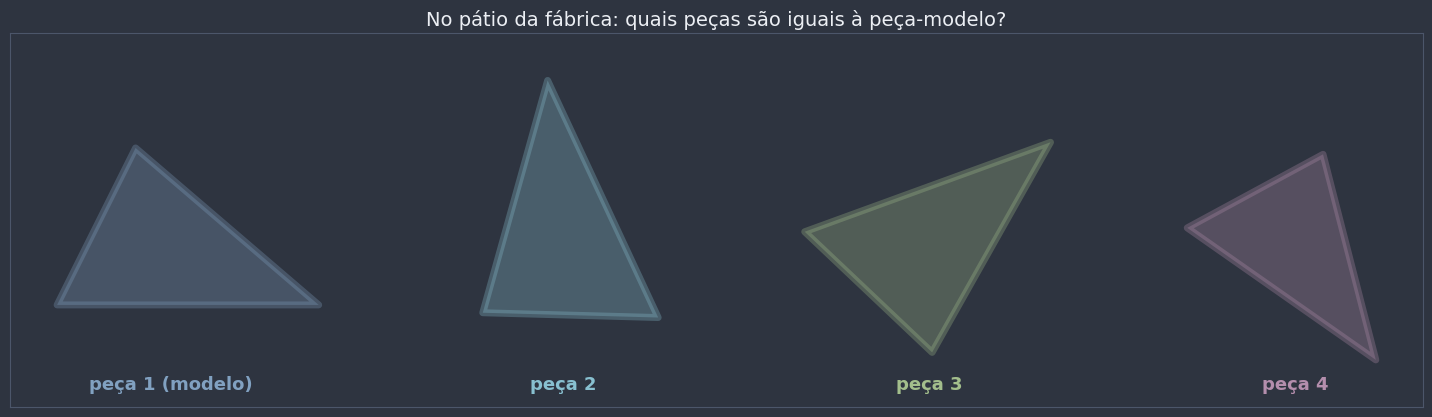

In [2]:
def mover(pontos, girar: float = 0, deslocar=(0, 0), espelhar: bool = False, escala: float = 1) -> list[np.ndarray]:
    """Leva uma figura para outra posição do plano, sem deformá-la: em torno do centro da figura,
    (opcionalmente) espelha, depois gira `girar` graus e, por fim, desloca por `deslocar`.

    Com `escala` diferente de 1 a figura também é ampliada ou reduzida, e aí ela DEIXA de ser
    uma cópia fiel: esse é o único parâmetro que "trapaceia".
    """
    pontos = [np.array(p, dtype=float) for p in pontos]
    centro = sum(pontos) / len(pontos)
    novos = []
    for p in pontos:
        x, y = escala * (p - centro)
        if espelhar:
            x = -x
        novos.append(centro + x * direcao(girar) + y * direcao(girar + 90) + np.array(deslocar, dtype=float))
    return novos


# O pátio da fábrica: a peça-modelo e três peças que saíram de outras máquinas
peca_modelo = [np.array(p, dtype=float) for p in [(0, 0), (5, 0), (1.5, 3)]]
pecas = {
    "peça 1 (modelo)": peca_modelo,
    "peça 2": mover(peca_modelo, girar=115, deslocar=(7.5, 0.3)),
    "peça 3": mover(peca_modelo, girar=200, deslocar=(14.5, 0.2), espelhar=True),
    "peça 4": mover(peca_modelo, girar=-35, deslocar=(21.5, 0.1), escala=0.88),
}

fig, ax = plt.subplots(figsize=(15, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)
todos = [p for peca in pecas.values() for p in peca]
preparar_eixo(ax, todos, margem=0.9)
for (nome, peca), cor in zip(pecas.items(), (COR_SECUNDARIA, COR_PONTO, COR_DESTAQUE, COR_EXTRA)):
    ax.add_patch(Polygon(peca, closed=True, facecolor=cor, alpha=0.3, edgecolor=cor, lw=5, joinstyle="round"))
    centro = sum(peca) / 3
    ax.text(centro[0], min(p[1] for p in todos) - 0.55, nome, color=cor, fontsize=13, ha="center",
            fontweight="bold")
ax.set_title("No pátio da fábrica: quais peças são iguais à peça-modelo?", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

Olhando, é difícil ter certeza. As peças 2 e 3 parecem iguais ao modelo, só giradas (e a 3 também foi **virada**). A peça 4 também parece... mas ela é um pouquinho **menor**. O olho engana; o inspetor precisa de **medidas**. Na seção 1 vamos definir com precisão o que é "ser a mesma peça" e, na seção 2, descobrir que bastam **três** medidas bem escolhidas para decidir.

## 1. O que significa dois triângulos serem congruentes

Você já conhece a palavra **congruente** para segmentos e ângulos:
- em [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb), dois segmentos são congruentes quando têm a **mesma medida** ($\overline{AB} \equiv \overline{CD}$);
- em [`0403a_angulos.ipynb`](0403a_angulos.ipynb), dois ângulos são congruentes quando têm a **mesma medida**, e você viu que dá para conferir isso por **superposição**.

Para figuras, a ideia é a mesma da superposição: duas figuras são **congruentes** quando uma pode ser levada sobre a outra, coincidindo **perfeitamente**, usando só **movimentos que não deformam**: deslizar (translação), girar (rotação) e virar como uma panqueca (reflexão). Em linguagem do dia a dia: **mesma forma e mesmo tamanho**.

Para triângulos, dá para transformar essa ideia numa lista de conferência. Quando o △DEF é colocado em cima do △ABC, cada vértice de um cai sobre um vértice do outro. Isso cria uma **correspondência** entre os vértices, e com ela vêm os lados e os ângulos correspondentes.

📌 **Definição formal (congruência de triângulos):** $\triangle ABC \equiv \triangle DEF$ quando, na correspondência $A \leftrightarrow D$, $B \leftrightarrow E$, $C \leftrightarrow F$, os três lados e os três ângulos correspondentes são, respectivamente, congruentes:

$$\overline{AB} \equiv \overline{DE}, \quad \overline{BC} \equiv \overline{EF}, \quad \overline{CA} \equiv \overline{FD}, \qquad \hat{A} \equiv \hat{D}, \quad \hat{B} \equiv \hat{E}, \quad \hat{C} \equiv \hat{F}$$

São **seis condições**. Os pares que aparecem nelas são os **elementos correspondentes**:

| Vértices correspondentes | Lados correspondentes | Ângulos correspondentes |
|---|---|---|
| A ↔ D | $\overline{AB}$ ↔ $\overline{DE}$ | $\hat{A}$ ↔ $\hat{D}$ |
| B ↔ E | $\overline{BC}$ ↔ $\overline{EF}$ | $\hat{B}$ ↔ $\hat{E}$ |
| C ↔ F | $\overline{CA}$ ↔ $\overline{FD}$ | $\hat{C}$ ↔ $\hat{F}$ |

**A ordem das letras é a mensagem.** Escrever $\triangle ABC \equiv \triangle DEF$ diz "1ª letra com 1ª letra, 2ª com 2ª, 3ª com 3ª". Para achar o lado que corresponde a $\overline{AB}$, pegue as **posições** de A e B (1ª e 2ª) e leia as mesmas posições do outro nome: $\overline{DE}$.

Para conferir as seis condições no computador, voltam as duas ferramentas do notebook anterior: a **distância** entre dois pontos, para os lados, e o **transferidor digital** `medir_angulo`, para os ângulos. Vamos testar com a peça-modelo e a peça 2 do gancho, chamando os vértices da peça 2 de D, E e F (D é a posição para onde o vértice A foi levado, e assim por diante).

In [3]:
def distancia(P, Q) -> float:
    """Distância entre os pontos P e Q do plano (a fórmula da distância de 0402a)."""
    return math.dist(P, Q)


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def elementos(P, Q, R) -> list[float]:
    """Os seis elementos do triângulo PQR, sempre nesta ordem: lados PQ, QR, RP e ângulos P̂, Q̂, R̂."""
    return [distancia(P, Q), distancia(Q, R), distancia(R, P),
            medir_angulo(P, Q, R), medir_angulo(Q, R, P), medir_angulo(R, P, Q)]


def nomes_dos_elementos(nomes: str) -> list[str]:
    """Nomes dos seis elementos, na mesma ordem de `elementos` (ex.: 'ABC' -> AB, BC, CA, Â, B̂, Ĉ)."""
    p, q, r = nomes
    return [p + q, q + r, r + p, p + "̂", q + "̂", r + "̂"]


def seis_condicoes(tri_1, tri_2, nomes_1: str = "ABC", nomes_2: str = "DEF", tolerancia: float = 1e-9) -> pd.DataFrame:
    """Confere as seis condições da definição, emparelhando os vértices NA ORDEM em que foram dados
    (1º com 1º, 2º com 2º, 3º com 3º)."""
    linhas = []
    for k, (n1, n2, m1, m2) in enumerate(zip(nomes_dos_elementos(nomes_1), nomes_dos_elementos(nomes_2),
                                              elementos(*tri_1), elementos(*tri_2))):
        unidade = "°" if k >= 3 else ""
        linhas.append({
            "condição": f"{n1} ≡ {n2}",
            f"medida em △{nomes_1}": f"{m1:.3f}{unidade}",
            f"medida em △{nomes_2}": f"{m2:.3f}{unidade}",
            "confere?": "✅" if math.isclose(m1, m2, rel_tol=tolerancia) else "❌",
        })
    return pd.DataFrame(linhas)


def congruentes_na_ordem(tri_1, tri_2, tolerancia: float = 1e-9) -> bool:
    """True se as seis condições valem com a correspondência 1º↔1º, 2º↔2º, 3º↔3º."""
    return all(math.isclose(m1, m2, rel_tol=tolerancia) for m1, m2 in zip(elementos(*tri_1), elementos(*tri_2)))


A, B, C = peca_modelo
D, E, F = pecas["peça 2"]
print(f"A = {A}, B = {B}, C = {C}")
print(f"D = ({D[0]:.3f}, {D[1]:.3f}), E = ({E[0]:.3f}, {E[1]:.3f}), F = ({F[0]:.3f}, {F[1]:.3f})\n")
display(seis_condicoes((A, B, C), (D, E, F)).style.hide(axis="index"))
print(f"△ABC ≡ △DEF?  {congruentes_na_ordem((A, B, C), (D, E, F))}")

A = [0. 0.], B = [5. 0.], C = [1.5 3. ]
D = (11.489, -0.241), E = (9.376, 4.290), F = (8.136, -0.149)



condição,medida em △ABC,medida em △DEF,confere?
AB ≡ DE,5.000,5.000,✅
BC ≡ EF,4.610,4.610,✅
CA ≡ FD,3.354,3.354,✅
Â ≡ D̂,63.435°,63.435°,✅
B̂ ≡ Ê,40.601°,40.601°,✅
Ĉ ≡ F̂,75.964°,75.964°,✅


△ABC ≡ △DEF?  True


As coordenadas são completamente diferentes (a peça 2 foi girada e deslocada), mas as seis medidas batem, uma a uma. Agora o desenho, no padrão dos livros: lados correspondentes recebem o **mesmo número de tracinhos** e ângulos correspondentes, a **mesma cor**.

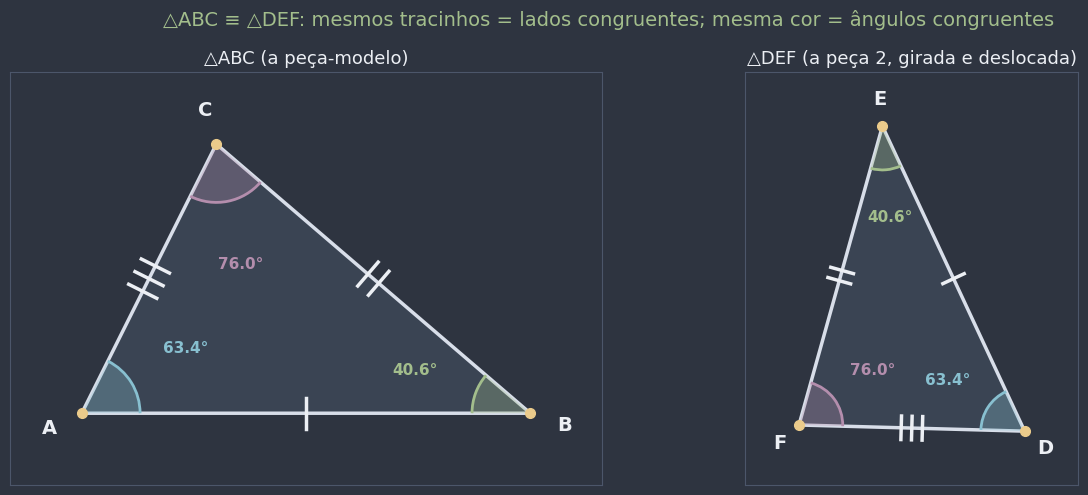

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(NORD_FUNDO)
# Tracinhos: 2 no lado oposto ao 1º vértice (BC), 3 no oposto ao 2º (CA) e 1 no oposto ao 3º (AB)
marcas = (2, 3, 1)

preparar_eixo(ax1, [A, B, C])
desenhar_triangulo(ax1, A, B, C, lados=False, marcas_lados=marcas,
                   rotulos_angulos=[f"{m:.1f}°" for m in elementos(A, B, C)[3:]])
ax1.set_title("△ABC (a peça-modelo)", color=NORD_TEXTO, fontsize=13)

preparar_eixo(ax2, [D, E, F])
desenhar_triangulo(ax2, D, E, F, nomes=("D", "E", "F"), lados=False, marcas_lados=marcas,
                   rotulos_angulos=[f"{m:.1f}°" for m in elementos(D, E, F)[3:]])
ax2.set_title("△DEF (a peça 2, girada e deslocada)", color=NORD_TEXTO, fontsize=13)

fig.suptitle("△ABC ≡ △DEF: mesmos tracinhos = lados congruentes; mesma cor = ângulos congruentes",
             color=COR_DESTAQUE, fontsize=14)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** escrever a congruência com os vértices na ordem errada. Os dois triângulos acima **são** congruentes, mas a frase "$\triangle ABC \equiv \triangle EFD$" é **falsa**: ela afirma que A corresponde a E, que $\overline{AB}$ corresponde a $\overline{EF}$, e assim por diante. A notação **não é livre**, ela comunica a correspondência. Veja o que acontece quando conferimos na ordem E, F, D:

In [5]:
display(seis_condicoes((A, B, C), (E, F, D), "ABC", "EFD").style.hide(axis="index"))
print(f"△ABC ≡ △EFD?  {congruentes_na_ordem((A, B, C), (E, F, D))}")

condição,medida em △ABC,medida em △EFD,confere?
AB ≡ EF,5.000,4.610,❌
BC ≡ FD,4.610,3.354,❌
CA ≡ DE,3.354,5.000,❌
Â ≡ Ê,63.435°,40.601°,❌
B̂ ≡ F̂,40.601°,75.964°,❌
Ĉ ≡ D̂,75.964°,63.435°,❌


△ABC ≡ △EFD?  False


E se ninguém nos disser qual vértice corresponde a qual? Três vértices podem ser emparelhados de $3 \cdot 2 \cdot 1 = 6$ maneiras. O computador pode testar **todas**: é só usar `permutations`, do módulo `itertools`, que gera todas as ordens possíveis. Vamos usar isso para responder, finalmente, a pergunta do gancho.

In [6]:
def buscar_correspondencias(tri_1, tri_2, nomes_2: str = "DEF", tolerancia: float = 1e-9) -> list[str]:
    """Testa as 6 maneiras de emparelhar os vértices e devolve as que funcionam, escritas como
    a ordem dos vértices do 2º triângulo (ex.: 'EFD' significa 1º↔E, 2º↔F, 3º↔D)."""
    achadas = []
    for ordem in permutations(range(3)):
        candidato = [tri_2[i] for i in ordem]
        if congruentes_na_ordem(tri_1, candidato, tolerancia):
            achadas.append("".join(nomes_2[i] for i in ordem))
    return achadas


print("Lista das 6 ordens que o computador testa:", ["".join("DEF"[i] for i in o) for o in permutations(range(3))], "\n")
linhas = []
for nome, peca in pecas.items():
    achadas = buscar_correspondencias(peca_modelo, peca)
    linhas.append({
        "peça": nome,
        "lados (ordenados)": ", ".join(f"{m:.2f}" for m in sorted(elementos(*peca)[:3])),
        "correspondências que funcionam": ", ".join(f"△ABC ≡ △{c}" for c in achadas) or "nenhuma",
        "é congruente ao modelo?": "✅" if achadas else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

Lista das 6 ordens que o computador testa: ['DEF', 'DFE', 'EDF', 'EFD', 'FDE', 'FED'] 



peça,lados (ordenados),correspondências que funcionam,é congruente ao modelo?
peça 1 (modelo),"3.35, 4.61, 5.00",△ABC ≡ △DEF,✅
peça 2,"3.35, 4.61, 5.00",△ABC ≡ △DEF,✅
peça 3,"3.35, 4.61, 5.00",△ABC ≡ △DEF,✅
peça 4,"2.95, 4.06, 4.40",nenhuma,❌


A peça 3 (a que foi **virada**) também é congruente: refletir não deforma nada. Já a peça 4 foi reduzida: os ângulos até são os mesmos, mas os lados não, e nenhuma das seis correspondências funciona. Ela vai para o lixo.

💡 **Dica:** num triângulo **isósceles** ou **equilátero**, mais de uma correspondência pode funcionar (no equilátero, todas as seis!). Não é erro: como há lados iguais, dá para encaixar a peça em cima da outra de mais de um jeito.

🕹️ **Widget interativo:** o △ABC (contorno tracejado) fica parado. O △DEF é uma cópia que você pode **deslocar**, **girar** e **espelhar** (virar como panqueca). A tabela abaixo do desenho confere as seis condições, na correspondência A↔D, B↔E, C↔F. Mexa à vontade nos três primeiros controles: a congruência nunca quebra. Depois mexa na `escala`, o único controle que **deforma** a figura, e veja quais condições deixam de valer.

In [7]:
def explorar_movimentos(deslocar: float, girar: int, espelhar: bool, escala: float) -> None:
    copia = mover(peca_modelo, girar=girar, deslocar=(deslocar, 0), espelhar=espelhar, escala=escala)
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-3.5, -3.8), (14.5, 6.2)], margem=0.1)
    desenhar_triangulo(ax, *peca_modelo, lados=False, angulos=False, cor_preenchimento=NORD_PAINEL,
                       estilo_borda="--", marcas_lados=(2, 3, 1))
    desenhar_triangulo(ax, *copia, nomes=("D", "E", "F"), lados=False, cor_preenchimento=COR_PONTO,
                       rotulos_angulos=[f"{m:.1f}°" for m in elementos(*copia)[3:]],
                       marcas_lados=(2, 3, 1) if math.isclose(escala, 1) else None)
    congruentes = congruentes_na_ordem(peca_modelo, copia)
    if congruentes:
        titulo, cor = "△ABC ≡ △DEF: as seis condições valem ✓", COR_DESTAQUE
    else:
        titulo, cor = f"escala {escala:g}: ângulos iguais, lados diferentes → NÃO é congruente ✗", COR_ALERTA
    ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()
    display(seis_condicoes(peca_modelo, copia).style.hide(axis="index"))


widgets.interact(
    explorar_movimentos,
    deslocar=widgets.FloatSlider(value=7, min=0, max=10, step=0.5, description="deslocar:"),
    girar=widgets.IntSlider(value=60, min=0, max=360, step=15, description="girar (°):"),
    espelhar=widgets.Checkbox(value=False, description="espelhar (virar a peça)"),
    escala=widgets.FloatSlider(value=1, min=0.5, max=1.5, step=0.1, description="escala:"),
);

interactive(children=(FloatSlider(value=7.0, description='deslocar:', max=10.0, step=0.5), IntSlider(value=60,…

Repare no que acontece com a `escala` diferente de 1: os três ângulos **continuam batendo**, só os lados mudam. Guarde isso: vai ser importante na seção 2, quando perguntarmos se "três ângulos iguais" bastam.

📖 **Leitura complementar:** [Congruência (geometria)](https://pt.wikipedia.org/wiki/Congru%C3%AAncia_(geometria))

**Pergunta de checagem:** se $\triangle ABC \equiv \triangle DEF$, qual é o lado do segundo triângulo que corresponde ao lado $\overline{AB}$? E qual ângulo corresponde a $\hat{C}$?

**Pergunta de checagem:** sabendo que $\triangle PQR \equiv \triangle XYZ$, a frase "$\triangle QRP \equiv \triangle YZX$" também é verdadeira? E "$\triangle QRP \equiv \triangle XYZ$"?

## 2. Os quatro casos de congruência

Conferir **seis** condições dá trabalho. A boa notícia: não é preciso. Lembra da rigidez? Três varetas travam o formato do triângulo. Então, se dois triângulos têm os três lados iguais, os ângulos **não têm escolha**: também saem iguais. Algumas escolhas de **três** informações já "travam" o triângulo inteiro, e as outras três condições vêm de brinde. São os **casos de congruência**:

| Caso | O que precisa ser congruente | Exemplo com △ABC e △DEF |
|---|---|---|
| **LAL** (lado-ângulo-lado) | dois lados e o ângulo **formado por eles** | $\overline{AB} \equiv \overline{DE}$, $\hat{A} \equiv \hat{D}$, $\overline{AC} \equiv \overline{DF}$ |
| **ALA** (ângulo-lado-ângulo) | dois ângulos e o lado **entre eles** | $\hat{A} \equiv \hat{D}$, $\overline{AB} \equiv \overline{DE}$, $\hat{B} \equiv \hat{E}$ |
| **LLL** (lado-lado-lado) | os três lados | $\overline{AB} \equiv \overline{DE}$, $\overline{BC} \equiv \overline{EF}$, $\overline{CA} \equiv \overline{FD}$ |
| **LAAo** (lado-ângulo-ângulo oposto) | um lado, um ângulo **adjacente** a ele e o ângulo **oposto** a ele | $\overline{AB} \equiv \overline{DE}$, $\hat{A} \equiv \hat{D}$, $\hat{C} \equiv \hat{F}$ |

📌 **Casos de congruência:** se dois triângulos satisfazem as três condições de **qualquer um** dos casos LAL, ALA, LLL ou LAAo, então eles são congruentes (e, portanto, as **seis** condições valem).

**A ordem das letras é um desenho.** Em **LAL**, o A está **entre** os dois L: o ângulo fica entre os lados, é o ângulo que eles formam. Em **ALA**, o L está entre os dois A: o lado liga os vértices dos dois ângulos. Em **LAAo**, o "o" de **oposto** avisa que o segundo ângulo fica do outro lado do triângulo, de frente para o lado conhecido.

**Por que funcionam?** Cada caso é uma **receita de construção** que só tem **um resultado** (a menos da posição no plano). Se duas fábricas seguem a mesma receita, fazem a mesma peça:
- **LAL:** desenhe o ângulo e marque os dois lados sobre ele. As duas pontas soltas só podem ser ligadas de **um** jeito.
- **ALA:** desenhe o lado e, em cada ponta, o ângulo dado. As duas semirretas se cruzam em **um único** ponto.
- **LLL:** deite um lado; o terceiro vértice está no cruzamento de duas circunferências (a construção das varetas de 0404a). Há dois cruzamentos, um em cima e outro embaixo, mas eles são **reflexos** um do outro, e portanto dão triângulos congruentes.
- **LAAo:** pela soma 180°, conhecer dois ângulos é conhecer os três. Então o ângulo que falta, na outra ponta do lado, sai de graça, e o problema **vira um ALA**.

📎 **Conexão:** em livros de geometria que seguem o estilo de Euclides, o caso **LAL** costuma ser aceito como **postulado** (lembra das proposições primitivas de [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb)?), e os outros três casos são **demonstrados** a partir dele. Aqui vamos nos convencer deles pela construção e pelos números.

No código, cada receita vira uma função. Duas delas você já conhece de 0404a (`construir_por_lados` e `construir_por_angulos`); as outras duas são novas.

In [8]:
def construir_por_lados(a: float, b: float, c: float):
    """Vértices (A, B, C) de um triângulo com BC = a, CA = b e AB = c, ou None se ele não existir (0404a).

    B fica em (0, 0) e C em (a, 0); A é o cruzamento da circunferência de centro B e raio c
    com a circunferência de centro C e raio b.
    """
    if min(a, b, c) <= 0:
        return None
    x = (a**2 + c**2 - b**2) / (2 * a)
    altura_ao_quadrado = c**2 - x**2
    if altura_ao_quadrado < -1e-9:
        return None
    return np.array([x, math.sqrt(max(altura_ao_quadrado, 0))]), np.array([0.0, 0.0]), np.array([float(a), 0.0])


def construir_por_angulos(alfa: float, beta: float, base: float = 5.0):
    """Vértices (A, B, C) de um triângulo com AB = base, Â = alfa e B̂ = beta (0404a).

    Devolve None se as semirretas que saem de A e de B não se encontram (alfa + beta >= 180°).
    """
    if alfa <= 0 or beta <= 0 or alfa + beta >= 180:
        return None
    A, B = np.array([0.0, 0.0]), np.array([float(base), 0.0])
    # C está ao mesmo tempo na semirreta de A (direção alfa) e na semirreta de B (direção 180° - beta)
    t, _ = np.linalg.solve(np.column_stack([direcao(alfa), -direcao(180 - beta)]), B - A)
    return A, B, A + t * direcao(alfa)


def construir_lal(lado_ab: float, angulo_a: float, lado_ac: float):
    """Receita LAL: vértices (A, B, C) com AB = lado_ab, Â = angulo_a e AC = lado_ac."""
    if min(lado_ab, lado_ac) <= 0 or not 0 < angulo_a < 180:
        return None
    A = np.array([0.0, 0.0])
    return A, A + lado_ab * direcao(0), A + lado_ac * direcao(angulo_a)


def construir_laao(lado_ab: float, angulo_a: float, angulo_c: float):
    """Receita LAAo: AB = lado_ab, Â = angulo_a (adjacente a AB) e Ĉ = angulo_c (oposto a AB).

    O ângulo B̂ sai da soma 180°, e a receita vira um ALA.
    """
    return construir_por_angulos(angulo_a, 180 - angulo_a - angulo_c, base=lado_ab)


def forma_triangulo(a: float, b: float, c: float) -> bool:
    """True se as medidas a, b e c formam um triângulo (desigualdade triangular, 0404a)."""
    if min(a, b, c) <= 0:
        return False
    return a < b + c and b < a + c and c < a + b


# Cada caso: a receita, os dados e quais elementos são DADOS (índices em elementos(): 0=AB, 1=BC, 2=CA, 3=Â, 4=B̂, 5=Ĉ)
receitas = {
    "LAL": (lambda: construir_lal(5, 50, 3.5), "AB = 5, Â = 50°, AC = 3,5", {0, 3, 2}),
    "ALA": (lambda: construir_por_angulos(50, 60, base=5), "Â = 50°, AB = 5, B̂ = 60°", {3, 0, 4}),
    "LLL": (lambda: construir_por_lados(4.5, 3.5, 5), "AB = 5, BC = 4,5, CA = 3,5", {0, 1, 2}),
    "LAAo": (lambda: construir_laao(5, 50, 70), "AB = 5, Â = 50°, Ĉ = 70°", {0, 3, 5}),
}
rotulos = ["AB", "BC", "CA", "Â", "B̂", "Ĉ"]
linhas = []
for caso, (receita, dados, indices_dados) in receitas.items():
    fabrica_1 = receita()
    # A fábrica 2 segue a mesma receita, mas a peça sai girada, virada e em outro lugar
    fabrica_2 = mover(receita(), girar=137, deslocar=(20, -7), espelhar=True)
    medidas = elementos(*fabrica_1)
    calculados = [f"{rotulos[k]} = {medidas[k]:.2f}{'°' if k >= 3 else ''}" for k in range(6) if k not in indices_dados]
    tabela = seis_condicoes(fabrica_1, fabrica_2)
    linhas.append({
        "caso": caso,
        "dados (3 medidas)": dados,
        "o que sai de brinde": ", ".join(calculados),
        "peça da fábrica 2 confere": f"{(tabela['confere?'] == '✅').sum()} de 6",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

caso,dados (3 medidas),o que sai de brinde,peça da fábrica 2 confere
LAL,"AB = 5, Â = 50°, AC = 3,5","BC = 3.84, B̂ = 44.27°, Ĉ = 85.73°",6 de 6
ALA,"Â = 50°, AB = 5, B̂ = 60°","BC = 4.08, CA = 4.61, Ĉ = 70.00°",6 de 6
LLL,"AB = 5, BC = 4,5, CA = 3,5","Â = 60.94°, B̂ = 42.83°, Ĉ = 76.23°",6 de 6
LAAo,"AB = 5, Â = 50°, Ĉ = 70°","BC = 4.08, CA = 4.61, B̂ = 60.00°",6 de 6


Em todos os casos, **três** medidas bastaram para descobrir as outras três, e a peça da segunda fábrica (girada, virada e deslocada) passou nas seis condições. Agora a representação gráfica de cada receita: em amarelo, o que foi **dado**; em verde, o que a construção **obriga** a acontecer.

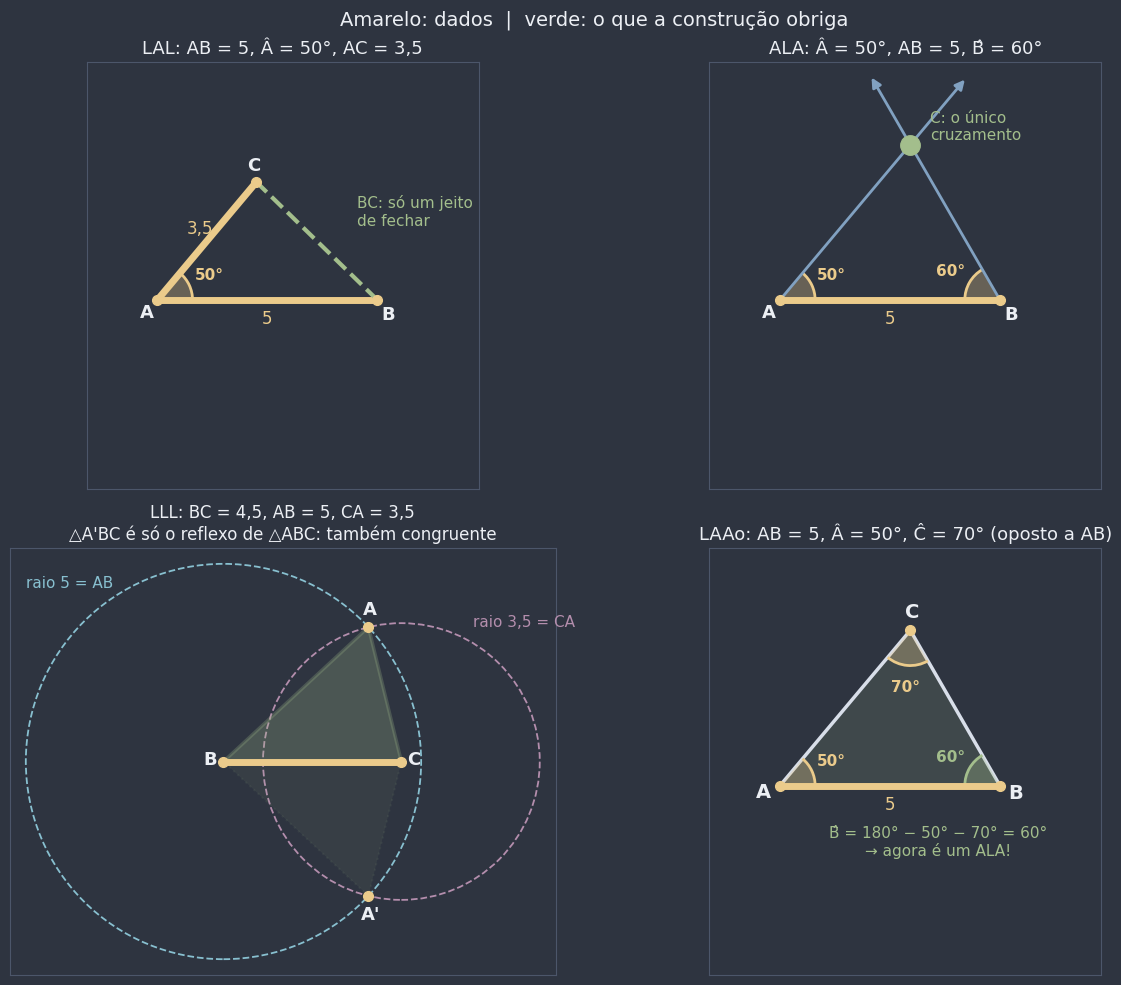

In [9]:
def semirreta(ax, origem, angulo: float, comprimento: float, cor: str) -> None:
    """Desenha uma semirreta (uma seta comprida) saindo de `origem` na direção `angulo`."""
    fim = np.array(origem, dtype=float) + comprimento * direcao(angulo)
    ax.annotate("", xy=fim, xytext=origem, arrowprops=dict(arrowstyle="-|>", color=cor, lw=2, mutation_scale=14))


fig, eixos = plt.subplots(2, 2, figsize=(13, 10))
fig.patch.set_facecolor(NORD_FUNDO)
quadro = [(-1.5, -4.2), (7.2, 5.3)]

# LAL: dois lados e o ângulo entre eles; o terceiro lado é forçado
ax = eixos[0, 0]
A, B, C = construir_lal(5, 50, 3.5)
preparar_eixo(ax, quadro, margem=0.1)
ax.plot(*zip(A, B), color=COR_AVISO, lw=5, solid_capstyle="round")
ax.plot(*zip(A, C), color=COR_AVISO, lw=5, solid_capstyle="round")
desenhar_arco(ax, A, B, C, raio=0.8, cor=COR_AVISO, rotulo="50°", raio_rotulo=1.3)
ax.plot(*zip(B, C), color=COR_DESTAQUE, lw=3, linestyle="--")
ax.text(*((B + C) / 2 + np.array([0.9, 0.35])), "BC: só um jeito\nde fechar", color=COR_DESTAQUE, fontsize=11)
for P, n, d in [(A, "A", (-0.4, -0.4)), (B, "B", (0.1, -0.45)), (C, "C", (-0.2, 0.25))]:
    desenhar_ponto(ax, P, n, deslocamento=d)
ax.text(2.5, -0.55, "5", color=COR_AVISO, fontsize=12, ha="center")
ax.text(*(C / 2 + np.array([-0.45, 0.15])), "3,5", color=COR_AVISO, fontsize=12)
ax.set_title("LAL: AB = 5, Â = 50°, AC = 3,5", color=NORD_TEXTO, fontsize=13)

# ALA: um lado e os dois ângulos das pontas; as semirretas se cruzam num só ponto
ax = eixos[0, 1]
A, B, C = construir_por_angulos(50, 60, base=5)
preparar_eixo(ax, quadro, margem=0.1)
ax.plot(*zip(A, B), color=COR_AVISO, lw=5, solid_capstyle="round")
semirreta(ax, A, 50, 6.6, COR_SECUNDARIA)
semirreta(ax, B, 120, 5.9, COR_SECUNDARIA)
desenhar_arco(ax, A, B, C, raio=0.8, cor=COR_AVISO, rotulo="50°", raio_rotulo=1.3)
desenhar_arco(ax, B, C, A, raio=0.8, cor=COR_AVISO, rotulo="60°", raio_rotulo=1.3)
ax.plot(*C, "o", color=COR_DESTAQUE, markersize=14, zorder=6)
ax.text(*(C + np.array([0.45, 0.1])), "C: o único\ncruzamento", color=COR_DESTAQUE, fontsize=11)
desenhar_ponto(ax, A, "A", deslocamento=(-0.4, -0.4))
desenhar_ponto(ax, B, "B", deslocamento=(0.1, -0.45))
ax.text(2.5, -0.55, "5", color=COR_AVISO, fontsize=12, ha="center")
ax.set_title("ALA: Â = 50°, AB = 5, B̂ = 60°", color=NORD_TEXTO, fontsize=13)

# LLL: um lado deitado e duas circunferências; os dois cruzamentos são reflexos
ax = eixos[1, 0]
A, B, C = construir_por_lados(4.5, 3.5, 5)  # A em cima; B = (0, 0), C = (4,5; 0)
A_espelho = np.array([A[0], -A[1]])
preparar_eixo(ax, [(-5.2, -5.2), (8.2, 5.2)], margem=0.2)
ax.add_patch(Circle(B, 5, fill=False, edgecolor=COR_PONTO, lw=1.3, linestyle="--"))
ax.add_patch(Circle(C, 3.5, fill=False, edgecolor=COR_EXTRA, lw=1.3, linestyle="--"))
ax.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_DESTAQUE, alpha=0.25, edgecolor=COR_DESTAQUE, lw=2.5))
ax.add_patch(Polygon([A_espelho, B, C], closed=True, facecolor=COR_DESTAQUE, alpha=0.08, edgecolor=COR_DESTAQUE,
                     lw=1.5, linestyle=":"))
ax.plot(*zip(B, C), color=COR_AVISO, lw=5, solid_capstyle="round")
for P, n, d in [(A, "A", (-0.15, 0.3)), (A_espelho, "A'", (-0.2, -0.6)), (B, "B", (-0.5, -0.1)), (C, "C", (0.15, -0.1))]:
    desenhar_ponto(ax, P, n, deslocamento=d)
ax.text(-5.0, 4.4, "raio 5 = AB", color=COR_PONTO, fontsize=11)
ax.text(6.3, 3.4, "raio 3,5 = CA", color=COR_EXTRA, fontsize=11)
ax.set_title("LLL: BC = 4,5, AB = 5, CA = 3,5\n△A'BC é só o reflexo de △ABC: também congruente", color=NORD_TEXTO,
             fontsize=12)

# LAAo: o ângulo oposto é trocado pelo ângulo que falta na outra ponta, e vira ALA
ax = eixos[1, 1]
A, B, C = construir_laao(5, 50, 70)
preparar_eixo(ax, quadro, margem=0.1)
ax.plot(*zip(A, B), color=COR_AVISO, lw=5, solid_capstyle="round")
desenhar_triangulo(ax, A, B, C, lados=False, angulos=False, cor_preenchimento=COR_DESTAQUE)
desenhar_arco(ax, A, B, C, raio=0.8, cor=COR_AVISO, rotulo="50°", raio_rotulo=1.3)
desenhar_arco(ax, C, A, B, raio=0.8, cor=COR_AVISO, rotulo="70°", raio_rotulo=1.3)
desenhar_arco(ax, B, C, A, raio=0.8, cor=COR_DESTAQUE, rotulo="60°", raio_rotulo=1.3)
ax.text(3.6, -1.6, "B̂ = 180° − 50° − 70° = 60°\n→ agora é um ALA!", color=COR_DESTAQUE, fontsize=11, ha="center")
ax.text(2.5, -0.55, "5", color=COR_AVISO, fontsize=12, ha="center")
ax.set_title("LAAo: AB = 5, Â = 50°, Ĉ = 70° (oposto a AB)", color=NORD_TEXTO, fontsize=13)

fig.suptitle("Amarelo: dados  |  verde: o que a construção obriga", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** escolha o caso no menu e ajuste as medidas. Para não se perder, os controles têm sempre o mesmo papel:
- `lado 1` é sempre $\overline{AB}$ e `ângulo 1` é sempre $\hat{A}$;
- `lado 2` é $\overline{AC}$ (usado no LAL e no LLL) e `lado 3` é $\overline{BC}$ (só no LLL);
- `ângulo 2` é $\hat{B}$ no ALA e $\hat{C}$ (o oposto a $\overline{AB}$) no LAAo.

Os controles que o caso não usa são simplesmente ignorados. À esquerda está a peça da fábrica 1; à direita, a da fábrica 2, feita com os **mesmos dados**, mas que saiu girada e virada. Em amarelo, os dados; em azul, o que foi calculado. Tente encontrar dados com os quais **não existe** triângulo em cada caso.

In [ ]:
def desenhar_com_dados(ax, pontos, nomes: str, dados: set[int]) -> None:
    """Desenha o triângulo com as seis medidas: em amarelo os elementos DADOS, em azul os calculados.
    Os índices de `dados` seguem a ordem de `elementos`: 0=1º lado, 1=2º, 2=3º, 3, 4, 5 = ângulos."""
    P = [np.array(p, dtype=float) for p in pontos]
    medidas = elementos(*P)
    tamanho = max(medidas[:3])
    centro = sum(P) / 3
    desenhar_triangulo(ax, *P, nomes=tuple(nomes), lados=False, angulos=False, cor_preenchimento=COR_SECUNDARIA)
    for k, (i, j) in enumerate([(0, 1), (1, 2), (2, 0)]):
        cor = COR_AVISO if k in dados else COR_SECUNDARIA
        ax.plot(*zip(P[i], P[j]), color=cor, lw=5 if k in dados else 2.5, solid_capstyle="round")
        meio = (P[i] + P[j]) / 2
        fora = (meio - centro) / np.linalg.norm(meio - centro)
        ax.text(*(meio + 0.09 * tamanho * fora), f"{medidas[k]:.2f}", color=cor, fontsize=11, ha="center",
                va="center", fontweight="bold")
    for k in range(3):
        cor = COR_AVISO if k + 3 in dados else COR_SECUNDARIA
        desenhar_arco(ax, P[k], P[(k + 1) % 3], P[(k + 2) % 3], raio=0.12 * tamanho, cor=cor,
                      rotulo=f"{medidas[k + 3]:.0f}°", raio_rotulo=0.25 * tamanho, tamanho_fonte=10)


def explorar_casos(caso: str, lado_1: float, lado_2: float, lado_3: float, angulo_1: int, angulo_2: int) -> None:
    if caso == "LAL":
        vertices, dados = construir_lal(lado_1, angulo_1, lado_2), {0, 3, 2}
        texto = f"AB = {lado_1:g}, Â = {angulo_1}°, AC = {lado_2:g}"
    elif caso == "ALA":
        vertices, dados = construir_por_angulos(angulo_1, angulo_2, base=lado_1), {3, 0, 4}
        texto = f"Â = {angulo_1}°, AB = {lado_1:g}, B̂ = {angulo_2}°"
    elif caso == "LLL":
        existe = forma_triangulo(lado_3, lado_2, lado_1)
        vertices = construir_por_lados(lado_3, lado_2, lado_1) if existe else None
        # construir_por_lados devolve (A, B, C) com B na origem; mantemos a ordem A, B, C
        dados = {0, 1, 2}
        texto = f"AB = {lado_1:g}, AC = {lado_2:g}, BC = {lado_3:g}"
    else:
        vertices, dados = construir_laao(lado_1, angulo_1, angulo_2), {0, 3, 5}
        texto = f"AB = {lado_1:g}, Â = {angulo_1}°, Ĉ = {angulo_2}° (oposto a AB)"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
    fig.patch.set_facecolor(NORD_FUNDO)
    if vertices is None:
        motivos = {
            "LAL": "",
            "ALA": f"Â + B̂ = {angulo_1 + angulo_2}° ≥ 180°: as semirretas não se cruzam",
            "LLL": "os lados não obedecem à desigualdade triangular",
            "LAAo": f"Â + Ĉ = {angulo_1 + angulo_2}° ≥ 180°: não sobra nada para B̂",
        }
        for ax in (ax1, ax2):
            preparar_eixo(ax, [(0, 0), (1, 1)], margem=0.1)
            ax.text(0.5, 0.5, "não existe\ntriângulo", color=COR_ALERTA, fontsize=20, ha="center", va="center",
                    fontweight="bold")
        fig.suptitle(f"{caso} com {texto}\n{motivos[caso]}", color=COR_ALERTA, fontsize=13)
    else:
        peca_1 = list(vertices)
        peca_2 = mover(peca_1, girar=140, espelhar=True)
        preparar_eixo(ax1, peca_1, margem=0.25 * max(elementos(*peca_1)[:3]))
        desenhar_com_dados(ax1, peca_1, "ABC", dados)
        ax1.set_title("fábrica 1: △ABC", color=NORD_TEXTO, fontsize=13)
        preparar_eixo(ax2, peca_2, margem=0.25 * max(elementos(*peca_2)[:3]))
        desenhar_com_dados(ax2, peca_2, "DEF", dados)
        confere = sum(math.isclose(m1, m2, rel_tol=1e-9) for m1, m2 in zip(elementos(*peca_1), elementos(*peca_2)))
        ax2.set_title(f"fábrica 2: △DEF (girada e virada) — {confere} de 6 condições ✓", color=COR_DESTAQUE,
                      fontsize=13)
        fig.suptitle(f"{caso} com {texto}  →  △ABC ≡ △DEF", color=NORD_TEXTO, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_casos,
    caso=widgets.Dropdown(options=["LAL", "ALA", "LLL", "LAAo"], value="LAL", description="caso:"),
    lado_1=widgets.FloatSlider(value=5, min=1, max=8, step=0.5, description="lado 1 (AB):"),
    lado_2=widgets.FloatSlider(value=4, min=1, max=8, step=0.5, description="lado 2 (AC):"),
    lado_3=widgets.FloatSlider(value=6, min=1, max=8, step=0.5, description="lado 3 (BC):"),
    angulo_1=widgets.IntSlider(value=50, min=10, max=170, step=5, description="ângulo 1 (Â):"),
    angulo_2=widgets.IntSlider(value=60, min=10, max=170, step=5, description="ângulo 2:"),
);

interactive(children=(Dropdown(description='caso:', options=('LAL', 'ALA', 'LLL', 'LAAo'), value='LAL'), Float…

🎯 **Aplicação prática — controle de qualidade na fábrica:** voltando ao gancho, o inspetor não precisa conferir seis medidas por peça, nem sobrepor peças pesadas. Pelo caso **LAL**, basta medir **dois lados e o ângulo entre eles**, e comparar com o molde, aceitando uma pequena **tolerância** (nenhuma medida real é perfeita). O terceiro lado, que ninguém mediu, fica automaticamente determinado: a tabela abaixo o calcula só para mostrar que ele também bate nas peças aprovadas.

In [11]:
molde = {"AB": 120.0, "Â": 60.0, "AC": 90.0}  # centímetros e graus
tolerancia_cm, tolerancia_graus = 0.5, 0.5
lado_bc_molde = distancia(*construir_lal(molde["AB"], molde["Â"], molde["AC"])[1:])

# Medidas feitas pelo inspetor: (AB, Â, AC) de cada peça que saiu da linha de produção
medicoes = {
    "peça 01": (120.2, 59.8, 89.9),
    "peça 02": (119.6, 60.3, 90.4),
    "peça 03": (120.1, 62.0, 90.0),
    "peça 04": (121.3, 60.0, 90.1),
    "peça 05": (120.4, 59.9, 90.2),
    "peça 06": (120.0, 60.0, 88.9),
}
linhas = []
for nome, (ab, angulo_a, ac) in medicoes.items():
    problemas = []
    if abs(ab - molde["AB"]) > tolerancia_cm:
        problemas.append("AB")
    if abs(angulo_a - molde["Â"]) > tolerancia_graus:
        problemas.append("Â")
    if abs(ac - molde["AC"]) > tolerancia_cm:
        problemas.append("AC")
    bc = distancia(*construir_lal(ab, angulo_a, ac)[1:])
    linhas.append({
        "peça": nome, "AB (cm)": ab, "Â (°)": angulo_a, "AC (cm)": ac,
        "BC calculado (cm)": bc, "diferença em BC (cm)": bc - lado_bc_molde,
        "resultado": "✅ aprovada" if not problemas else "❌ reprovada (" + ", ".join(problemas) + ")",
    })
print(f"Molde: AB = {molde['AB']:g} cm, Â = {molde['Â']:g}°, AC = {molde['AC']:g} cm  →  BC = {lado_bc_molde:.2f} cm")
print(f"Tolerância: ±{tolerancia_cm} cm nos lados e ±{tolerancia_graus}° no ângulo\n")
display(pd.DataFrame(linhas).style.format({"AB (cm)": "{:.1f}", "Â (°)": "{:.1f}", "AC (cm)": "{:.1f}",
                                           "BC calculado (cm)": "{:.2f}", "diferença em BC (cm)": "{:+.2f}"})
        .hide(axis="index"))

Molde: AB = 120 cm, Â = 60°, AC = 90 cm  →  BC = 108.17 cm
Tolerância: ±0.5 cm nos lados e ±0.5° no ângulo



peça,AB (cm),Â (°),AC (cm),BC calculado (cm),diferença em BC (cm),resultado
peça 01,120.2,59.8,89.9,107.98,-0.19,✅ aprovada
peça 02,119.6,60.3,90.4,108.46,+0.29,✅ aprovada
peça 03,120.1,62.0,90.0,111.24,+3.08,❌ reprovada (Â)
peça 04,121.3,60.0,90.1,109.10,+0.93,❌ reprovada (AB)
peça 05,120.4,59.9,90.2,108.35,+0.18,✅ aprovada
peça 06,120.0,60.0,88.9,107.87,-0.30,❌ reprovada (AC)


Repare na peça 03: os dois lados estão perfeitos, mas o ângulo errado em 2° faz o terceiro lado mudar mais de 1 cm. No LAL, o ângulo **entre** os lados é tão importante quanto os próprios lados.

### Nem todo trio de informações funciona

São seis elementos e escolhemos três, então existem outras combinações além dos quatro casos. Duas delas **parecem** casos de congruência, mas **não são**.

**AAA (três ângulos):** lembra da `escala` no widget da seção 1? Ampliar ou reduzir um triângulo mantém os três ângulos e muda os lados. Ou seja, triângulos com os mesmos três ângulos podem ter **tamanhos diferentes**. (E, na verdade, AAA dá só **duas** informações independentes: o terceiro ângulo já sai dos outros dois pela soma 180°.)

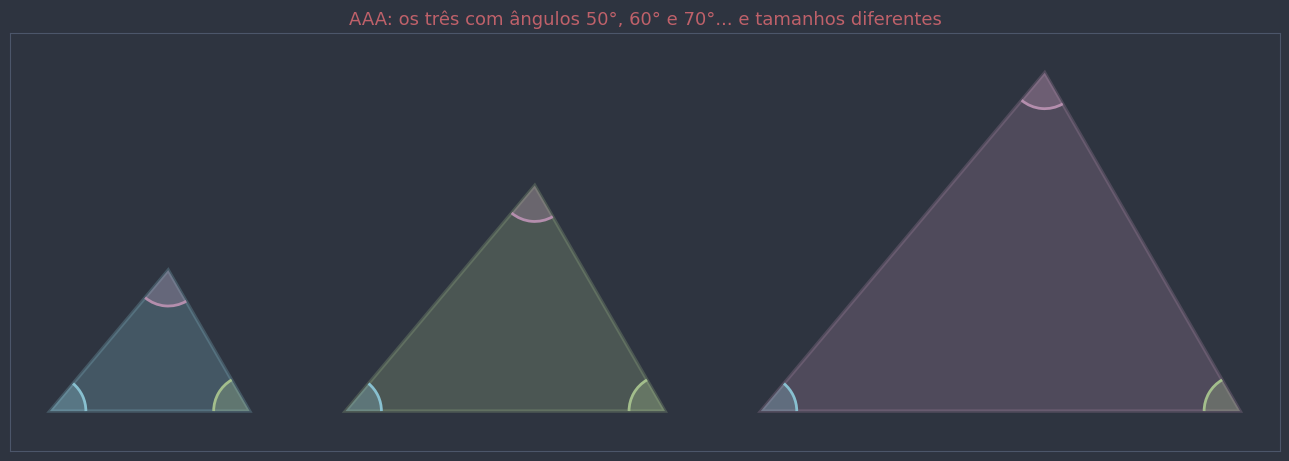

triângulo,Â,B̂,Ĉ,AB,BC,CA
base 2.5,50.0°,60.0°,70.0°,2.50,2.04,2.30
base 4,50.0°,60.0°,70.0°,4.00,3.26,3.69
base 6,50.0°,60.0°,70.0°,6.00,4.89,5.53


In [12]:
fig, ax = plt.subplots(figsize=(13, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
linhas = []
inicio_x = 0.0
todos = []
for base, cor in [(2.5, COR_PONTO), (4, COR_DESTAQUE), (6, COR_EXTRA)]:
    A, B, C = construir_por_angulos(50, 60, base=base)
    A, B, C = A + [inicio_x, 0], B + [inicio_x, 0], C + [inicio_x, 0]
    todos += [A, B, C]
    ax.add_patch(Polygon([A, B, C], closed=True, facecolor=cor, alpha=0.25, edgecolor=cor, lw=2.5))
    for k, P in enumerate((A, B, C)):
        vizinhos = [(A, B, C)[(k + 1) % 3], (A, B, C)[(k + 2) % 3]]
        desenhar_arco(ax, P, *vizinhos, raio=0.45, cor=CORES_VERTICES[k])
    medidas = elementos(A, B, C)
    linhas.append({"triângulo": f"base {base:g}", "Â": f"{medidas[3]:.1f}°", "B̂": f"{medidas[4]:.1f}°",
                   "Ĉ": f"{medidas[5]:.1f}°", "AB": f"{medidas[0]:.2f}", "BC": f"{medidas[1]:.2f}",
                   "CA": f"{medidas[2]:.2f}"})
    inicio_x += base + 1.2
preparar_eixo(ax, todos, margem=0.5)
ax.set_title("AAA: os três com ângulos 50°, 60° e 70°... e tamanhos diferentes", color=COR_ALERTA, fontsize=13)
plt.tight_layout()
plt.show()
display(pd.DataFrame(linhas).style.hide(axis="index"))

📎 **Conexão:** triângulos com os mesmos ângulos não são congruentes, mas também não são "quaisquer": um é uma **ampliação** do outro, como uma foto ampliada ou reduzida. Eles são **semelhantes**, e esse é o tema de 📌 Semelhança de Triângulos e Potência de Ponto.

**LLA (dois lados e um ângulo que NÃO fica entre eles):** fixe $\overline{AB} = 6$ e $\hat{A} = 30^\circ$, e diga que o lado $\overline{BC}$, que fica **de frente** para o ângulo $\hat{A}$, mede 4. O vértice C precisa estar na semirreta que sai de A com abertura de 30° e, ao mesmo tempo, a uma distância 4 de B, ou seja, na **circunferência** de centro B e raio 4. Quantas vezes a circunferência corta a semirreta?

In [13]:
def solucoes_lla(lado_ab: float, angulo_a: float, lado_bc: float) -> list[np.ndarray]:
    """Posições possíveis do vértice C quando se conhecem AB, o ângulo Â e o lado BC (oposto a Â).

    Com A = (0, 0) e B = (AB, 0), C está na semirreta que sai de A com abertura Â e, ao mesmo
    tempo, na circunferência de centro B e raio BC. Resolvendo o cruzamento (uma equação do
    2º grau na distância t de A até C), sobram 0, 1 ou 2 soluções com t > 0.
    """
    u = direcao(angulo_a)
    B = np.array([lado_ab, 0.0])
    projecao = float(np.dot(u, B))
    delta = projecao**2 - lado_ab**2 + lado_bc**2
    if delta < -1e-12:
        return []
    raiz = math.sqrt(max(delta, 0))
    distancias_t = sorted({round(t, 12) for t in (projecao - raiz, projecao + raiz) if t > 1e-9})
    return [t * u for t in distancias_t]


linhas = []
for lado_bc in [2, 3, 4, 5, 5.9, 6, 7, 8]:
    solucoes = solucoes_lla(6, 30, lado_bc)
    linhas.append({
        "BC (oposto a Â)": lado_bc,
        "BC comparado a AB = 6": "menor" if lado_bc < 6 else "maior ou igual",
        "quantos triângulos": len(solucoes),
        "medidas possíveis de AC": ", ".join(f"{distancia((0, 0), C):.2f}" for C in solucoes) or "—",
    })
print("AB = 6 e Â = 30° fixos; só o lado BC muda.\n")
display(pd.DataFrame(linhas).style.format({"BC (oposto a Â)": "{:g}"}).hide(axis="index"))

AB = 6 e Â = 30° fixos; só o lado BC muda.



BC (oposto a Â),BC comparado a AB = 6,quantos triângulos,medidas possíveis de AC
2,menor,0,—
3,menor,1,5.20
4,menor,2,"2.55, 7.84"
5,menor,2,"1.20, 9.20"
5.9,menor,2,"0.12, 10.28"
6,maior ou igual,1,10.39
7,maior ou igual,1,11.52
8,maior ou igual,1,12.61


Com BC = 4 (e também 5 ou 5,9) aparecem **dois** triângulos **diferentes**, com os mesmos dados. Então "dois lados e um ângulo qualquer" **não garante** congruência. Mas repare na última parte da tabela: quando o lado oposto ao ângulo dado é **maior ou igual** ao outro lado conhecido, o triângulo volta a ser **único**.

🕹️ **Widget interativo:** $\overline{AB} = 6$ e $\hat{A} = 30^\circ$ estão fixos. Mova o slider de $\overline{BC}$ e veja a circunferência de centro B cortar a semirreta de A em **zero**, **um** ou **dois** pontos. Os dois triângulos, quando aparecem, têm os mesmos três dados e formatos claramente diferentes.

In [14]:
def explorar_lla(lado_bc: float) -> None:
    lado_ab, angulo_a = 6.0, 30.0
    A, B = np.array([0.0, 0.0]), np.array([lado_ab, 0.0])
    solucoes = solucoes_lla(lado_ab, angulo_a, lado_bc)
    fig, ax = plt.subplots(figsize=(10, 5.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1, -3.5), (15.5, 7.6)], margem=0.1)
    ax.add_patch(Circle(B, lado_bc, fill=False, edgecolor=COR_EXTRA, lw=1.5, linestyle="--"))
    semirreta(ax, A, angulo_a, 15, NORD_TEXTO_SEC)
    for C, cor in zip(solucoes, (COR_DESTAQUE, COR_ALERTA)):
        ax.add_patch(Polygon([A, B, C], closed=True, facecolor=cor, alpha=0.2, edgecolor=cor, lw=3))
        ax.plot(*C, "o", color=cor, markersize=11, zorder=6)
        ax.text(*(C + np.array([0.2, 0.35])), f"AC = {distancia(A, C):.2f}", color=cor, fontsize=11)
    ax.plot(*zip(A, B), color=COR_AVISO, lw=5, solid_capstyle="round")
    desenhar_setor(ax, A, 0, angulo_a, raio=1.2, cor=COR_AVISO, rotulo="30°", raio_rotulo=1.8)
    desenhar_ponto(ax, A, "A", deslocamento=(-0.5, -0.5))
    desenhar_ponto(ax, B, "B", deslocamento=(0.1, -0.55))
    ax.text(3, -0.6, "AB = 6", color=COR_AVISO, fontsize=11, ha="center")
    if not solucoes:
        titulo, cor = f"BC = {lado_bc:g}: a circunferência nem alcança a semirreta → nenhum triângulo", COR_ALERTA
    elif len(solucoes) == 1:
        titulo, cor = f"BC = {lado_bc:g}: um único triângulo", COR_DESTAQUE
    else:
        titulo, cor = f"BC = {lado_bc:g}: DOIS triângulos diferentes com os mesmos dados → LLA não garante!", COR_AVISO
    ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_lla,
    lado_bc=widgets.FloatSlider(value=4, min=1.5, max=9, step=0.25, description="BC:"),
);

interactive(children=(FloatSlider(value=4.0, description='BC:', max=9.0, min=1.5, step=0.25), Output()), _dom_…

⚠️ **Erro comum:** usar "LLA" como se fosse um caso de congruência. Dois lados e um ângulo que **não** fica entre eles só garantem congruência numa situação especial: quando o ângulo conhecido fica **oposto ao maior** dos dois lados (como você viu no widget, com $BC \geq AB$). O exemplo mais importante dessa situação é o triângulo **retângulo** com **hipotenusa e um cateto** congruentes: o ângulo de 90° fica oposto à hipotenusa, que é o maior lado. Não confunda LLA com **LAAo**, que é um caso válido sempre. As letras dos casos não estão em ordem arbitrária: elas descrevem **onde** cada elemento está.

🎯 **Aplicação prática — triangulação:** em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) você mediu a largura de um rio com uma **base** e **dois ângulos**, sem atravessar a água. Agora dá para dizer **por que** isso funciona: um lado e os dois ângulos das pontas é exatamente o caso **ALA**. Qualquer topógrafo que medir a mesma base e os mesmos ângulos vai obter um triângulo **congruente**, e portanto a mesma distância até a árvore. É o que garante que a medida é confiável. Navegadores e agrimensores usam essa ideia há séculos para mapear terrenos e litorais.

🕵️ **Curiosidade histórica — Tales e os navios:** conta o historiador grego Eudemo (século IV a.C.), num relato preservado por Proclo, que **Tales de Mileto** (por volta de 600 a.C.) sabia calcular a que distância da costa estava um navio, e que o método dele dependia do caso **ALA**. Não se sabe exatamente como Tales fazia, mas uma reconstrução comum é esta: da praia, medindo uma base e os ângulos até o navio, dá para montar um triângulo **congruente** inteiramente em terra firme, onde a distância pode ser medida com os pés no chão. O caso ALA aparece mais tarde como a Proposição 26 do Livro I dos *Elementos* de Euclides, e o LAL como a Proposição 4.

📖 **Leitura complementar:** [Congruência triangular](https://pt.wikipedia.org/wiki/Congru%C3%AAncia_triangular) · [Triangulação](https://pt.wikipedia.org/wiki/Triangula%C3%A7%C3%A3o_(geometria))

**Pergunta de checagem:** dois triângulos têm dois lados congruentes e um ângulo congruente que **não** fica entre esses dois lados. Dá para garantir que são congruentes? Em que situação especial dá?

**Pergunta de checagem:** num triângulo sabemos $\hat{A} = 40^\circ$, $\hat{B} = 75^\circ$ e $\overline{BC} = 7$. O lado $\overline{BC}$ fica entre $\hat{A}$ e $\hat{B}$? Qual caso você usaria para garantir que qualquer triângulo com esses dados é congruente a este?

## 3. Usando a congruência para demonstrar propriedades

Até aqui, comparamos triângulos que alguém nos deu prontos. Mas o uso mais poderoso da congruência é outro: ela é uma **ferramenta de demonstração**. A estratégia é sempre a mesma:
1. **encontrar** (ou **construir**, traçando um segmento auxiliar) dois triângulos na figura;
2. provar que eles são congruentes por um dos quatro casos;
3. **colher** as outras condições que vêm de brinde: se os triângulos são congruentes, **todos** os seus elementos correspondentes são congruentes.

Vamos usar essa estratégia para pagar uma dívida. Em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb), a propriedade do triângulo isósceles foi **enunciada** e aceita olhando desenhos e números. Agora ela vai ser **demonstrada**.

📌 **Teorema (triângulo isósceles):** se um triângulo tem dois lados congruentes, então os ângulos da base são congruentes.

- **Hipótese** (o que sabemos): no $\triangle ABC$, $\overline{AB} \equiv \overline{AC}$ (a base é $\overline{BC}$).
- **Tese** (o que queremos provar): $\hat{B} \equiv \hat{C}$.

**Construção auxiliar:** trace a **bissetriz** do ângulo do vértice $\hat{A}$ (você viu bissetrizes em [`0403a_angulos.ipynb`](0403a_angulos.ipynb)). Ela corta a base $\overline{BC}$ num ponto D e divide o triângulo em dois: $\triangle ABD$ e $\triangle ACD$.

**Demonstração:**

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $\overline{AB} \equiv \overline{AC}$ | hipótese (o triângulo é isósceles) |
| 2 | $B\hat{A}D \equiv C\hat{A}D$ | $\overline{AD}$ é a bissetriz de $\hat{A}$: divide o ângulo em dois ângulos congruentes |
| 3 | $\overline{AD} \equiv \overline{AD}$ | lado **comum** aos dois triângulos (todo segmento é congruente a si mesmo: propriedade reflexiva, de 0402a) |
| 4 | $\triangle ABD \equiv \triangle ACD$ | caso **LAL**, pelos passos 1, 3 e 2 (o ângulo do passo 2 fica **entre** os lados dos passos 1 e 3) |
| 5 | $\hat{B} \equiv \hat{C}$ | na correspondência A↔A, B↔C, D↔D, o ângulo $\hat{B}$ corresponde a $\hat{C}$; elementos correspondentes de triângulos congruentes são congruentes ∎ |

O símbolo ∎ marca o fim de uma demonstração.

**Os brindes.** Do passo 4 saem mais duas conclusões, de graça:
- $\overline{BD} \equiv \overline{CD}$: o ponto D é o **ponto médio** da base. Então a bissetriz do ângulo do vértice também é a **mediana** (o segmento que liga um vértice ao ponto médio do lado oposto).
- $A\hat{D}B \equiv A\hat{D}C$: e como esses dois ângulos são **suplementares** (juntos formam o ângulo raso $B\hat{D}C$), cada um mede $180^\circ / 2 = 90^\circ$. A bissetriz também é **perpendicular** à base.

💡 **Dica — outro caminho:** em vez da bissetriz, dá para traçar o segmento de A até o **ponto médio** M da base. Aí os lados dos dois triângulos são $\overline{AB} \equiv \overline{AC}$ (hipótese), $\overline{BM} \equiv \overline{CM}$ (M é ponto médio) e $\overline{AM}$ comum: é o caso **LLL**, e a conclusão $\hat{B} \equiv \hat{C}$ é a mesma. Os dois caminhos levam ao mesmo segmento: no isósceles, a bissetriz do vértice e a mediana da base **coincidem**.

O computador não substitui a demonstração (ela vale para **todos** os isósceles; o código confere um de cada vez), mas é ótimo para **ver** o que ela afirma. Vamos construir um isósceles por coordenadas, traçar o segmento até o ponto médio da base e conferir os dois sub-triângulos.

In [15]:
def triangulo_isosceles(meia_base: float, altura: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Isósceles com o vértice A em cima do meio da base: A = (0, altura), B = (−meia_base, 0), C = (meia_base, 0)."""
    return np.array([0.0, altura]), np.array([-meia_base, 0.0]), np.array([meia_base, 0.0])


A, B, C = triangulo_isosceles(meia_base=3, altura=4.5)
M = (B + C) / 2
print(f"A = {A}, B = {B}, C = {C}, M (ponto médio de BC) = {M}")
print(f"AB = {distancia(A, B):.4f} e AC = {distancia(A, C):.4f}  →  isósceles de base BC\n")

print("Sub-triângulos ABM e ACM, na correspondência A↔A, B↔C, M↔M:")
display(seis_condicoes((A, B, M), (A, C, M), "ABM", "ACM").style.hide(axis="index"))

print(f"B̂ = {medir_angulo(B, A, C):.4f}°  e  Ĉ = {medir_angulo(C, A, B):.4f}°  →  ângulos da base congruentes ✅")
print(f"BÂM = {medir_angulo(A, B, M):.4f}°  e  CÂM = {medir_angulo(A, C, M):.4f}°  →  AM também é bissetriz ✅")
print(f"AM̂B = {medir_angulo(M, A, B):.4f}°  e  AM̂C = {medir_angulo(M, A, C):.4f}°  →  AM é perpendicular à base ✅")

A = [0.  4.5], B = [-3.  0.], C = [3. 0.], M (ponto médio de BC) = [0. 0.]
AB = 5.4083 e AC = 5.4083  →  isósceles de base BC

Sub-triângulos ABM e ACM, na correspondência A↔A, B↔C, M↔M:


condição,medida em △ABM,medida em △ACM,confere?
AB ≡ AC,5.408,5.408,✅
BM ≡ CM,3.000,3.000,✅
MA ≡ MA,4.500,4.500,✅
Â ≡ Â,33.690°,33.690°,✅
B̂ ≡ Ĉ,56.310°,56.310°,✅
M̂ ≡ M̂,90.000°,90.000°,✅


B̂ = 56.3099°  e  Ĉ = 56.3099°  →  ângulos da base congruentes ✅
BÂM = 33.6901°  e  CÂM = 33.6901°  →  AM também é bissetriz ✅
AM̂B = 90.0000°  e  AM̂C = 90.0000°  →  AM é perpendicular à base ✅


🕹️ **Widget interativo:** a base $\overline{BC}$ tem medida 6 e fica fixa; o slider controla a **altura** do vértice A, sempre em cima do ponto médio M da base, de modo que $\overline{AB} \equiv \overline{AC}$ o tempo todo. Os dois sub-triângulos aparecem com **cores espelhadas**: cada elemento de $\triangle ABM$ tem a mesma cor do seu correspondente em $\triangle ACM$. Estique e achate o triângulo e confira no título: os ângulos da base mudam, mas continuam **sempre iguais entre si**, as duas metades de $\hat{A}$ também, e o ângulo em M fica cravado em 90°.

In [16]:
def explorar_isosceles(altura: float) -> None:
    A, B, C = triangulo_isosceles(meia_base=3, altura=altura)
    M = (B + C) / 2
    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-4.2, -1.0), (4.2, 8.8)], margem=0.1)
    ax.add_patch(Polygon([A, B, M], closed=True, facecolor=COR_PONTO, alpha=0.22, edgecolor="none"))
    ax.add_patch(Polygon([A, C, M], closed=True, facecolor=COR_EXTRA, alpha=0.22, edgecolor="none"))
    ax.add_patch(Polygon([A, B, C], closed=True, fill=False, edgecolor=NORD_TEXTO_SEC, lw=2.5))
    ax.plot(*zip(A, M), color=COR_AVISO, lw=2.5, linestyle="--")
    raio = min(0.7, 0.3 * altura)
    angulo_base = medir_angulo(B, A, C)
    meio_a = medir_angulo(A, B, M)
    desenhar_arco(ax, B, C, A, raio=raio, cor=COR_DESTAQUE, rotulo=f"{angulo_base:.1f}°", raio_rotulo=raio + 0.6)
    desenhar_arco(ax, C, A, B, raio=raio, cor=COR_DESTAQUE, rotulo=f"{medir_angulo(C, A, B):.1f}°",
                  raio_rotulo=raio + 0.6)
    desenhar_arco(ax, A, B, M, raio=raio, cor=COR_AVISO)
    desenhar_arco(ax, A, M, C, raio=raio, cor=COR_AVISO)
    desenhar_setor(ax, M, 90, 90, raio=0.5, cor=COR_SECUNDARIA)
    desenhar_setor(ax, M, 0, 90, raio=0.5, cor=COR_SECUNDARIA)
    marcar_tracinhos(ax, A, B, 1, tamanho=0.18)
    marcar_tracinhos(ax, A, C, 1, tamanho=0.18)
    marcar_tracinhos(ax, B, M, 2, tamanho=0.18)
    marcar_tracinhos(ax, M, C, 2, tamanho=0.18)
    desenhar_ponto(ax, A, "A", deslocamento=(0.2, 0.1))
    desenhar_ponto(ax, B, "B", deslocamento=(-0.45, -0.45))
    desenhar_ponto(ax, C, "C", deslocamento=(0.15, -0.45))
    desenhar_ponto(ax, M, "M", deslocamento=(0.1, -0.5))
    ax.text(-1.5, -0.9, "△ABM", color=COR_PONTO, fontsize=13, ha="center", fontweight="bold")
    ax.text(1.5, -0.9, "△ACM", color=COR_EXTRA, fontsize=13, ha="center", fontweight="bold")
    ax.set_title(f"B̂ = Ĉ = {angulo_base:.1f}°   |   BÂM = CÂM = {meio_a:.1f}°   |   AM̂B = AM̂C = "
                 f"{medir_angulo(M, A, B):.0f}°", color=NORD_TEXTO, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_isosceles,
    altura=widgets.FloatSlider(value=4.5, min=0.75, max=8, step=0.25, description="altura:"),
);

interactive(children=(FloatSlider(value=4.5, description='altura:', max=8.0, min=0.75, step=0.25), Output()), …

💡 **Dica:** guarde esse segmento $\overline{AM}$. No triângulo isósceles, ele é ao mesmo tempo **bissetriz** do ângulo do vértice, **mediana** relativa à base, **altura** (é perpendicular à base) e está sobre a **mediatriz** da base (a reta perpendicular a $\overline{BC}$ pelo ponto médio). Esses quatro segmentos notáveis reaparecem em 📌 Pontos Notáveis do Triângulo, onde, num triângulo qualquer, eles são quatro segmentos **diferentes**; o isósceles é o caso particular em que coincidem.

🎯 **Aplicação prática — dobrar ao meio:** o que a demonstração fez foi, no fundo, **dobrar** o triângulo isósceles ao longo de $\overline{AM}$: a metade da esquerda cai exatamente sobre a da direita. É o mesmo teste que você faz ao dobrar ao meio o desenho de uma **borboleta** para ver se as asas são simétricas. Toda figura com um **eixo de simetria** tem essa propriedade: cada pedaço de um lado é **congruente** ao seu reflexo do outro lado. Engenheiros usam isso para projetar peças simétricas (asas de avião, pontes, carrocerias) calculando só **metade** delas.

🕹️ **Widget interativo:** a borboleta abaixo tem um triângulo marcado em cada asa: $\triangle PQR$ na direita e $\triangle XYZ$ na esquerda. O slider `dobra` fecha a asa esquerda sobre a direita, girando em torno do corpo (o eixo de simetria). Em 180° as asas ficam uma sobre a outra, e os dois triângulos coincidem.

In [18]:
# Meia borboleta (lado direito); o lado esquerdo é o reflexo em torno do eixo x = 0
asa_de_cima = [(0.15, 0.3), (1.0, 2.2), (2.4, 3.3), (3.6, 3.1), (3.7, 1.9), (2.6, 0.9), (0.2, 0.1)]
asa_de_baixo = [(0.2, -0.05), (1.9, -0.4), (2.9, -1.5), (2.5, -2.7), (1.4, -2.6), (0.15, -0.6)]
triangulo_direita = [np.array(p) for p in [(1.4, 1.5), (2.8, 2.6), (3.1, 1.6)]]
triangulo_esquerda = [np.array([-x, y]) for x, y in triangulo_direita]

print("Correspondências que funcionam entre △PQR (asa direita) e △XYZ (asa esquerda):",
      buscar_correspondencias(triangulo_direita, triangulo_esquerda, nomes_2="XYZ"))
print("(P↔X, Q↔Y, R↔Z: cada ponto corresponde ao seu reflexo.)\n")


def explorar_borboleta(dobra: int) -> None:
    # Fechar a asa esquerda: a coordenada x "encolhe" e depois troca de lado, como numa folha dobrada vista de cima
    fator = math.cos(math.radians(dobra))

    def dobrar(pontos):
        return [np.array([fator * x, y]) for x, y in ((-px, py) for px, py in pontos)]

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-4.2, -3.2), (4.2, 3.8)], margem=0.1)
    for asa in (asa_de_cima, asa_de_baixo):
        ax.add_patch(Polygon(asa, closed=True, facecolor=COR_PONTO, alpha=0.35, edgecolor=COR_PONTO, lw=2))
        ax.add_patch(Polygon(dobrar(asa), closed=True, facecolor=COR_EXTRA, alpha=0.35, edgecolor=COR_EXTRA, lw=2))
    ax.add_patch(Polygon(triangulo_direita, closed=True, facecolor=COR_AVISO, alpha=0.5, edgecolor=COR_AVISO, lw=2.5))
    ax.add_patch(Polygon(dobrar(triangulo_direita), closed=True, facecolor=COR_DESTAQUE, alpha=0.5,
                         edgecolor=COR_DESTAQUE, lw=2.5))
    for P, nome in zip(triangulo_direita, "PQR"):
        ax.text(*(P + np.array([0.12, 0.12])), nome, color=COR_AVISO, fontsize=12, fontweight="bold")
    for P, nome in zip(dobrar(triangulo_direita), "XYZ"):
        ax.text(*(P + np.array([-0.3, -0.3])), nome, color=COR_DESTAQUE, fontsize=12, fontweight="bold")
    ax.add_patch(Polygon([(-0.18, 0.6), (0.18, 0.6), (0.12, -1.6), (-0.12, -1.6)], closed=True,
                         facecolor=NORD_TEXTO_SEC, alpha=0.9))
    ax.plot([0, 0], [-3.1, 3.7], color=COR_AVISO, lw=1.5, linestyle="--")
    if dobra == 180:
        titulo, cor = "Dobrada: as asas coincidem, e △XYZ cai exatamente sobre △PQR", COR_DESTAQUE
    elif dobra == 0:
        titulo, cor = "Asas abertas: mova o slider para dobrar a asa esquerda sobre a direita", NORD_TEXTO
    else:
        titulo, cor = f"dobra = {dobra}°: a asa esquerda está fechando sobre a direita", NORD_TEXTO
    ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_borboleta,
    dobra=widgets.IntSlider(value=0, min=0, max=180, step=15, description="dobra (°):"),
);

Correspondências que funcionam entre △PQR (asa direita) e △XYZ (asa esquerda): ['XYZ']
(P↔X, Q↔Y, R↔Z: cada ponto corresponde ao seu reflexo.)



interactive(children=(IntSlider(value=0, description='dobra (°):', max=180, step=15), Output()), _dom_classes=…

**Pergunta de checagem:** na demonstração pela bissetriz, por que o caso usado é **LAL**, e não LLA? Onde fica o ângulo $B\hat{A}D$ em relação aos lados $\overline{AB}$ e $\overline{AD}$?

**Pergunta de checagem:** se, em vez da bissetriz, traçarmos o segmento de A até o **ponto médio** M da base, qual caso de congruência garante que $\triangle ABM \equiv \triangle ACM$? Quais são os três pares de elementos congruentes usados?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Figuras congruentes | uma pode ser levada sobre a outra só deslizando, girando ou refletindo: **mesma forma e mesmo tamanho** |
| Congruência de triângulos | $\triangle ABC \equiv \triangle DEF$: com $A \leftrightarrow D$, $B \leftrightarrow E$, $C \leftrightarrow F$, os **3 lados** e os **3 ângulos** correspondentes são congruentes (6 condições) |
| A notação | a **ordem** das letras indica a correspondência: 1ª↔1ª, 2ª↔2ª, 3ª↔3ª; o lado correspondente a $\overline{AB}$ é $\overline{DE}$ |
| **LAL** | dois lados e o ângulo **formado por eles** |
| **ALA** | dois ângulos e o lado **entre eles** |
| **LLL** | os três lados (é a rigidez do triângulo) |
| **LAAo** | um lado, um ângulo **adjacente** e o ângulo **oposto** a ele (vira ALA pela soma 180°) |
| **AAA** não é caso | mesmos ângulos, tamanhos diferentes: é **semelhança** |
| **LLA** não é caso | em geral pode haver **dois** triângulos; só vale se o ângulo for oposto ao **maior** dos dois lados (ex.: hipotenusa e cateto no triângulo retângulo) |
| Congruência como prova | ache (ou construa) dois triângulos, prove a congruência por um caso e colha os elementos correspondentes |
| Isósceles | $\overline{AB} \equiv \overline{AC} \Rightarrow \hat{B} \equiv \hat{C}$ (bissetriz do vértice + LAL); o segmento do vértice ao ponto médio da base é bissetriz, mediana e altura |

**A ideia central:** para garantir que dois triângulos são "o mesmo", não é preciso conferir seis medidas: **três**, bem escolhidas, travam o triângulo inteiro. E, uma vez provada a congruência, as outras três medidas vêm de graça, o que transforma a congruência numa das ferramentas de demonstração mais usadas de toda a geometria.

## Exercícios

**Básico**
1. Identificar qual caso de congruência (se algum) se aplica a cada par de triângulos descrito.
2. Listar os elementos correspondentes a partir de uma congruência escrita, e usar isso para descobrir medidas.

**Intermediário**

3. Escrever uma função que decide, a partir das coordenadas dos vértices, se dois triângulos são congruentes.
4. Verificar com código que dois triângulos retângulos com hipotenusa e um cateto congruentes são congruentes.

**Desafio**

5. Mostrar que a diagonal divide um paralelogramo em dois triângulos congruentes e tirar daí que os lados opostos são congruentes.
6. Reconstruir as medidas que faltam de um triângulo "parcialmente apagado" usando o caso ALA.

Gabarito completo com resolução comentada em [`0405b_congruencia_de_triangulos_gabarito.ipynb`](0405b_congruencia_de_triangulos_gabarito.ipynb) — tente resolver sozinho antes de olhar.

In [18]:
# Ferramenta usada pelas células de verificação: execute esta célula antes dos exercícios.
import unicodedata


def normalizar(texto) -> str:
    """Tira acentos, espaços extras e maiúsculas, para aceitar 'laao' tanto quanto 'LAAo'."""
    sem_acento = unicodedata.normalize("NFD", str(texto)).encode("ascii", "ignore").decode()
    return sem_acento.strip().lower()


def mesmo_segmento(resposta, certo: str) -> bool:
    """Compara nomes de segmentos aceitando as duas ordens das letras (LM é o mesmo que ML)."""
    return resposta is not ... and sorted(normalizar(resposta)) == sorted(normalizar(certo))

### Básico

In [ ]:
# Exercício Básico 1: para cada par de triângulos △ABC e △DEF descrito abaixo, diga qual
# caso de congruência garante que eles são congruentes: "LAL", "ALA", "LLL" ou "LAAo".
# Se as informações NÃO garantem a congruência, responda "nenhum".
#   (a) AB = DE = 5, B̂ = Ê = 40°, BC = EF = 7
#   (b) Â = D̂ = 50°, AB = DE = 6, B̂ = Ê = 70°
#   (c) AB = DE = 4, BC = EF = 5, CA = FD = 6
#   (d) Â = D̂ = 30°, B̂ = Ê = 60°, Ĉ = F̂ = 90°
#   (e) AB = DE = 8, Â = D̂ = 35°, Ĉ = F̂ = 80°
#   (f) AB = DE = 6, BC = EF = 4, Â = D̂ = 30°
# Responda com uma lista de textos, na ordem (a) a (f).
casos_ex1 = [..., ..., ..., ..., ..., ...]

print(casos_ex1)

In [ ]:
# Verificação
gabarito_ex1 = ["LAL", "ALA", "LLL", "nenhum", "LAAo", "nenhum"]
dicas_ex1 = [
    "o ângulo B̂ fica ENTRE os lados AB e BC (seção 2 - Os quatro casos de congruência).",
    "o lado AB liga os vértices dos dois ângulos dados (seção 2 - Os quatro casos de congruência).",
    "os três lados são congruentes (seção 2 - Os quatro casos de congruência).",
    "três ângulos iguais permitem tamanhos diferentes: é semelhança, não congruência "
    "(seção 2 - Os quatro casos de congruência).",
    "Â encosta em AB, mas Ĉ fica de frente para AB (seção 2 - Os quatro casos de congruência).",
    "o ângulo Â não fica entre AB e BC, e BC é o lado menor: é o LLA do widget "
    "(seção 2 - Os quatro casos de congruência).",
]
assert casos_ex1 is not ... and len(casos_ex1) == 6, (
    "Tente de novo, revise: a lista precisa ter uma resposta para cada um dos 6 itens "
    "(seção 2 - Os quatro casos de congruência)."
)
for item, resposta, certa, dica in zip("abcdef", casos_ex1, gabarito_ex1, dicas_ex1):
    assert resposta is not ... and normalizar(resposta) == normalizar(certa), (
        f"Tente de novo, revise o item ({item}): {dica}"
    )
print("Certo!")

In [ ]:
# Exercício Básico 2: sabe-se que △PQR ≡ △LMN.
# (a) Complete os dicionários com o elemento do △LMN que corresponde a cada elemento do △PQR.
#     Lados como texto de duas letras (ex.: "XY") e ângulos pela letra do vértice (ex.: "X").
# (b) Se PQ = 7 cm e Q̂ = 48°, quanto medem o lado LM (em cm) e o ângulo M̂ (em graus)?
#     E se RP = 9 cm, qual lado do △LMN também mede 9 cm? (texto de duas letras)
lados_ex2 = {"PQ": ..., "QR": ..., "RP": ...}
angulos_ex2 = {"P": ..., "Q": ..., "R": ...}

medida_LM_ex2 = ...
medida_M_ex2 = ...
lado_de_9cm_ex2 = ...

print(lados_ex2, angulos_ex2)
print(medida_LM_ex2, medida_M_ex2, lado_de_9cm_ex2)

In [ ]:
# Verificação
for lado, certo in {"PQ": "LM", "QR": "MN", "RP": "NL"}.items():
    assert mesmo_segmento(lados_ex2.get(lado, ...), certo), (
        f"Tente de novo, revise: para achar o correspondente de {lado}, veja as POSIÇÕES dessas letras "
        "em PQR e leia as mesmas posições em LMN (seção 1 - O que significa dois triângulos serem congruentes)."
    )
for vertice, certo in {"P": "L", "Q": "M", "R": "N"}.items():
    resposta = angulos_ex2.get(vertice, ...)
    assert resposta is not ... and normalizar(resposta).replace("̂", "") == normalizar(certo), (
        f"Tente de novo, revise: o ângulo {vertice}̂ corresponde ao vértice na MESMA posição em LMN "
        "(seção 1 - O que significa dois triângulos serem congruentes)."
    )
assert medida_LM_ex2 is not ... and math.isclose(medida_LM_ex2, 7), (
    "Tente de novo, revise: LM é o correspondente de PQ, e elementos correspondentes são congruentes "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
assert medida_M_ex2 is not ... and math.isclose(medida_M_ex2, 48), (
    "Tente de novo, revise: M̂ é o correspondente de Q̂ "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
assert mesmo_segmento(lado_de_9cm_ex2, "NL"), (
    "Tente de novo, revise: RP ocupa a 3ª e a 1ª posições; leia as mesmas posições em LMN "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: complete a função `sao_congruentes_ex3`, que recebe dois triângulos,
# cada um como uma lista com as coordenadas dos três vértices, e devolve True se eles forem
# congruentes e False caso contrário.
# Atenção: os vértices podem vir em QUALQUER ordem, e o triângulo pode estar girado ou refletido.
# Dica: pelo caso LLL, basta comparar os três lados... mas em que ordem? Pense em ordenar.
# Use `distancia` (seção 1) e compare medidas com math.isclose, nunca com ==.
# Não vale chamar `buscar_correspondencias`: a ideia é montar a sua versão, mais curta!
# (Se aparecer NameError, rode antes as células da seção 1.)


def sao_congruentes_ex3(triangulo_1, triangulo_2) -> bool:
    ...


print(sao_congruentes_ex3([(0, 0), (4, 0), (1, 3)], [(1, 3), (0, 0), (4, 0)]))

In [ ]:
# Verificação
modelo_ex3 = [(0, 0), (4, 0), (1, 3)]
casos_ex3 = [
    ([(10, 5), (14, 5), (11, 8)], True, "o mesmo triângulo, só deslocado"),
    ([(0, 0), (0, 4), (-3, 1)], True, "o mesmo triângulo, girado 90°"),
    ([(0, 0), (-4, 0), (-1, 3)], True, "o mesmo triângulo, refletido"),
    ([(1, 3), (0, 0), (4, 0)], True, "os mesmos vértices em outra ordem"),
    ([(0, 0), (8, 0), (2, 6)], False, "o triângulo ampliado 2 vezes (mesmos ângulos!)"),
    ([(0, 0), (4, 0), (2, 3)], False, "um triângulo com só um lado igual"),
    ([(0, 0), (4, 0), (3, 1)], False, "um triângulo com dois lados iguais aos do modelo"),
]
for outro, certo, descricao in casos_ex3:
    resposta = sao_congruentes_ex3(modelo_ex3, outro)
    assert resposta is certo, (
        f"Tente de novo, revise: para {descricao}, a função deveria devolver {certo}; compare os três "
        "lados de cada triângulo depois de ORDENÁ-LOS, com math.isclose (seção 2 - Os quatro casos de congruência)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: hipotenusa e cateto.
# Os triângulos retângulos T1 = △R1P1Q1 e T2 = △R2P2Q2 abaixo têm o ângulo reto em R1 e em R2,
# a mesma hipotenusa (13) e um cateto igual (R1P1 = R2P2 = 5). T2 foi girado e deslocado.
# (a) Use `medir_angulo` para conferir os ângulos retos: guarde as medidas de R̂1 e R̂2 em
#     `angulo_R1_ex4` e `angulo_R2_ex4`.
# (b) Use `distancia` para medir o OUTRO cateto de cada triângulo (R1Q1 e R2Q2). Guarde em
#     `outro_cateto_t1_ex4` e `outro_cateto_t2_ex4`.
# (c) Com o resultado de (b), qual caso de congruência garante agora que T1 ≡ T2?
#     Guarde o texto em `caso_ex4`.
# (d) Este exemplo parece um "LLA" (dois lados e um ângulo fora deles), que em geral NÃO é caso
#     de congruência. Aqui funciona porque o ângulo conhecido (90°) é oposto a qual lado:
#     "hipotenusa" ou "cateto"? Guarde o texto em `lado_oposto_ao_reto_ex4`.
R1, P1, Q1 = (0, 0), (5, 0), (0, 12)
R2, P2, Q2 = (10, 2), (13, 6), (0.4, 9.2)

angulo_R1_ex4 = ...
angulo_R2_ex4 = ...
outro_cateto_t1_ex4 = ...
outro_cateto_t2_ex4 = ...
caso_ex4 = ...
lado_oposto_ao_reto_ex4 = ...

print(angulo_R1_ex4, angulo_R2_ex4, outro_cateto_t1_ex4, outro_cateto_t2_ex4, caso_ex4, lado_oposto_ao_reto_ex4)

In [ ]:
# Verificação
assert angulo_R1_ex4 is not ... and math.isclose(angulo_R1_ex4, 90), (
    "Tente de novo, revise: o vértice do ângulo é R1 e os lados passam por P1 e Q1: "
    "medir_angulo(R1, P1, Q1) (seção 1 - O que significa dois triângulos serem congruentes)."
)
assert angulo_R2_ex4 is not ... and math.isclose(angulo_R2_ex4, 90), (
    "Tente de novo, revise: meça o ângulo com vértice em R2, entre P2 e Q2 "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
assert outro_cateto_t1_ex4 is not ... and math.isclose(outro_cateto_t1_ex4, 12), (
    "Tente de novo, revise: o outro cateto de T1 é o segmento R1Q1 "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
assert outro_cateto_t2_ex4 is not ... and math.isclose(outro_cateto_t2_ex4, 12), (
    "Tente de novo, revise: o outro cateto de T2 é o segmento R2Q2 "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
assert caso_ex4 is not ... and normalizar(caso_ex4) in ("lll", "lal"), (
    "Tente de novo, revise: agora você conhece os três lados de cada triângulo "
    "(seção 2 - Os quatro casos de congruência)."
)
assert lado_oposto_ao_reto_ex4 is not ... and normalizar(lado_oposto_ao_reto_ex4) == "hipotenusa", (
    "Tente de novo, revise: o LLA só funciona quando o ângulo conhecido é oposto ao MAIOR dos dois lados "
    "(seção 2 - Os quatro casos de congruência)."
)
print("Certo!")

### Desafio

Execute a célula abaixo para ver a figura do Exercício Desafio 5.

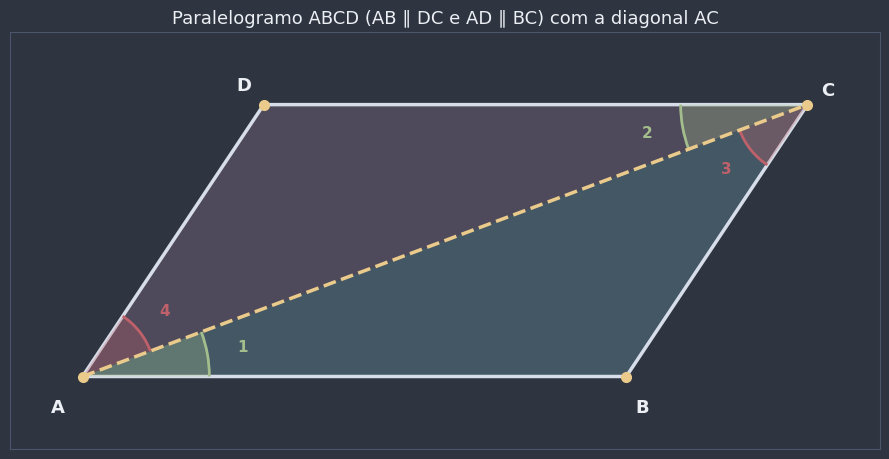

In [19]:
# Figura do Exercício Desafio 5 (apenas desenha; não precisa alterar)
A5, B5, C5, D5 = np.array([0.0, 0.0]), np.array([6.0, 0.0]), np.array([8.0, 3.0]), np.array([2.0, 3.0])
fig, ax = plt.subplots(figsize=(9, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A5, B5, C5, D5], margem=0.8)
ax.add_patch(Polygon([A5, B5, C5], closed=True, facecolor=COR_PONTO, alpha=0.25, edgecolor="none"))
ax.add_patch(Polygon([C5, D5, A5], closed=True, facecolor=COR_EXTRA, alpha=0.25, edgecolor="none"))
ax.add_patch(Polygon([A5, B5, C5, D5], closed=True, fill=False, edgecolor=NORD_TEXTO_SEC, lw=2.5))
ax.plot(*zip(A5, C5), color=COR_AVISO, lw=2.5, linestyle="--")
desenhar_arco(ax, A5, B5, C5, raio=1.4, cor=COR_DESTAQUE, rotulo="1", raio_rotulo=1.8)
desenhar_arco(ax, C5, D5, A5, raio=1.4, cor=COR_DESTAQUE, rotulo="2", raio_rotulo=1.8)
desenhar_arco(ax, C5, A5, B5, raio=0.8, cor=COR_ALERTA, rotulo="3", raio_rotulo=1.15)
desenhar_arco(ax, A5, C5, D5, raio=0.8, cor=COR_ALERTA, rotulo="4", raio_rotulo=1.15)
for P, nome, d in [(A5, "A", (-0.35, -0.4)), (B5, "B", (0.1, -0.4)), (C5, "C", (0.15, 0.1)), (D5, "D", (-0.3, 0.15))]:
    desenhar_ponto(ax, P, nome, deslocamento=d)
ax.set_title("Paralelogramo ABCD (AB ∥ DC e AD ∥ BC) com a diagonal AC", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 5: o paralelogramo e a sua diagonal.
# Um paralelogramo é um quadrilátero com os lados opostos paralelos (você vai estudá-lo com
# calma mais adiante no módulo). A diagonal AC divide o paralelogramo ABCD da figura em
# △ABC e △CDA.
# (a) Use `medir_angulo` para medir os ângulos marcados na figura:
#     ângulo 1 = BÂC, ângulo 2 = DĈA, ângulo 3 = BĈA, ângulo 4 = DÂC.
#     Guarde em `angulo_1_ex5`, `angulo_2_ex5`, `angulo_3_ex5` e `angulo_4_ex5`.
# (b) Os ângulos 1 e 2 são congruentes, os ângulos 3 e 4 também, e AC é lado comum aos dois
#     triângulos. Que caso de congruência é esse? Guarde o texto em `caso_ex5`.
# (c) Complete a congruência △ABC ≡ △_ _ _ com as letras na ordem correta (texto de três
#     letras). Guarde em `correspondencia_ex5`.
# (d) Use a correspondência para descobrir qual lado de △CDA corresponde a AB e qual
#     corresponde a BC (textos de duas letras). Guarde em `lado_de_AB_ex5` e `lado_de_BC_ex5`.
#     Conclusão: os lados opostos de um paralelogramo são congruentes!
angulo_1_ex5 = ...
angulo_2_ex5 = ...
angulo_3_ex5 = ...
angulo_4_ex5 = ...
caso_ex5 = ...
correspondencia_ex5 = ...
lado_de_AB_ex5 = ...
lado_de_BC_ex5 = ...

print(angulo_1_ex5, angulo_2_ex5, angulo_3_ex5, angulo_4_ex5)
print(caso_ex5, correspondencia_ex5, lado_de_AB_ex5, lado_de_BC_ex5)

In [ ]:
# Verificação
for nome, resposta, certo in [
    ("1 = BÂC", angulo_1_ex5, medir_angulo(A5, B5, C5)),
    ("2 = DĈA", angulo_2_ex5, medir_angulo(C5, D5, A5)),
    ("3 = BĈA", angulo_3_ex5, medir_angulo(C5, B5, A5)),
    ("4 = DÂC", angulo_4_ex5, medir_angulo(A5, D5, C5)),
]:
    assert resposta is not ... and math.isclose(resposta, certo), (
        f"Tente de novo, revise: no ângulo {nome}, a letra do meio é o vértice, que vai no 1º argumento de "
        "medir_angulo (seção 1 - O que significa dois triângulos serem congruentes)."
    )
assert caso_ex5 is not ... and normalizar(caso_ex5) == "ala", (
    "Tente de novo, revise: dois ângulos e o lado que liga os seus vértices "
    "(seção 2 - Os quatro casos de congruência)."
)
assert correspondencia_ex5 is not ... and normalizar(correspondencia_ex5) == "cda", (
    "Tente de novo, revise: o ângulo em A de △ABC (ângulo 1) é congruente ao ângulo em C de △CDA (ângulo 2), "
    "então A↔C; faça o mesmo com os outros vértices (seção 1 - O que significa dois triângulos serem congruentes)."
)
assert mesmo_segmento(lado_de_AB_ex5, "CD"), (
    "Tente de novo, revise: AB ocupa as posições 1 e 2 em ABC; leia as mesmas posições do outro nome "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
assert mesmo_segmento(lado_de_BC_ex5, "DA"), (
    "Tente de novo, revise: BC ocupa as posições 2 e 3 em ABC; leia as mesmas posições do outro nome "
    "(seção 1 - O que significa dois triângulos serem congruentes)."
)
print("Certo!")

Execute a célula abaixo para ver a figura do Exercício Desafio 6.

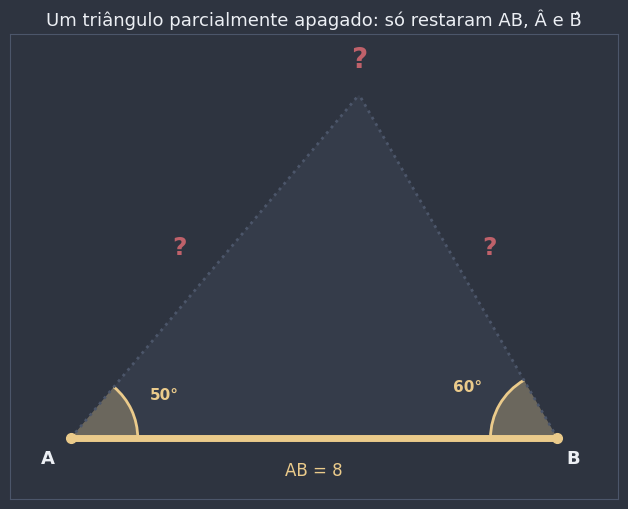

In [20]:
# Figura do Exercício Desafio 6 (apenas desenha; não precisa alterar)
A6, B6, C6 = construir_por_angulos(50, 60, base=8)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A6, B6, C6], margem=1.0)
ax.add_patch(Polygon([A6, B6, C6], closed=True, facecolor=NORD_PAINEL, alpha=0.6, edgecolor="none"))
ax.plot(*zip(A6, C6), color=NORD_LINHA, lw=2, linestyle=":")
ax.plot(*zip(B6, C6), color=NORD_LINHA, lw=2, linestyle=":")
ax.plot(*zip(A6, B6), color=COR_AVISO, lw=5, solid_capstyle="round")
desenhar_arco(ax, A6, B6, C6, raio=1.1, cor=COR_AVISO, rotulo="50°", raio_rotulo=1.7)
desenhar_arco(ax, B6, C6, A6, raio=1.1, cor=COR_AVISO, rotulo="60°", raio_rotulo=1.7)
ax.text(*(C6 + np.array([0, 0.45])), "?", color=COR_ALERTA, fontsize=20, ha="center", fontweight="bold")
ax.text(*((A6 + C6) / 2 + np.array([-0.7, 0.2])), "?", color=COR_ALERTA, fontsize=18, fontweight="bold")
ax.text(*((B6 + C6) / 2 + np.array([0.4, 0.2])), "?", color=COR_ALERTA, fontsize=18, fontweight="bold")
ax.text(4, -0.6, "AB = 8", color=COR_AVISO, fontsize=12, ha="center")
desenhar_ponto(ax, A6, "A", deslocamento=(-0.5, -0.4))
desenhar_ponto(ax, B6, "B", deslocamento=(0.15, -0.4))
ax.set_title("Um triângulo parcialmente apagado: só restaram AB, Â e B̂", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 6: reconstruindo o triângulo apagado da figura (AB = 8, Â = 50°, B̂ = 60°).
# (a) Quanto mede o ângulo Ĉ, que foi apagado? Guarde em `angulo_C_ex6`.
# (b) Use `construir_por_angulos` (seção 2) para refazer o triângulo com esses dados e
#     `distancia` para medir os lados apagados. Guarde as medidas de AC e BC em `lado_AC_ex6`
#     e `lado_BC_ex6`.
# (c) Outra equipe, em outro lugar, mediu um triângulo DEF com DE = 8, D̂ = 50° e Ê = 60°.
#     Qual caso de congruência garante que △DEF ≡ △ABC? Guarde o texto em `caso_ex6`.
# (d) Então dá para afirmar, SEM medir, que DF tem a mesma medida que AC? Guarde True ou
#     False em `df_igual_ac_ex6`.
angulo_C_ex6 = ...
lado_AC_ex6 = ...
lado_BC_ex6 = ...
caso_ex6 = ...
df_igual_ac_ex6 = ...

print(angulo_C_ex6, lado_AC_ex6, lado_BC_ex6, caso_ex6, df_igual_ac_ex6)

In [ ]:
# Verificação
assert angulo_C_ex6 is not ... and math.isclose(angulo_C_ex6, 70), (
    "Tente de novo, revise: os três ângulos internos somam 180° "
    "(seção 2 - Os quatro casos de congruência)."
)
# Medidas esperadas, calculadas por um caminho diferente (a lei dos senos, de Trigonometria)
esperado_ac = 8 * math.sin(math.radians(60)) / math.sin(math.radians(70))
esperado_bc = 8 * math.sin(math.radians(50)) / math.sin(math.radians(70))
assert lado_AC_ex6 is not ... and math.isclose(lado_AC_ex6, esperado_ac, rel_tol=1e-6), (
    "Tente de novo, revise: construa com construir_por_angulos(50, 60, base=8) e meça a distância entre "
    "o 1º e o 3º vértices (seção 2 - Os quatro casos de congruência)."
)
assert lado_BC_ex6 is not ... and math.isclose(lado_BC_ex6, esperado_bc, rel_tol=1e-6), (
    "Tente de novo, revise: meça a distância entre o 2º e o 3º vértices do triângulo construído "
    "(seção 2 - Os quatro casos de congruência)."
)
assert caso_ex6 is not ... and normalizar(caso_ex6) == "ala", (
    "Tente de novo, revise: um lado e os dois ângulos das suas pontas "
    "(seção 2 - Os quatro casos de congruência)."
)
assert df_igual_ac_ex6 is True, (
    "Tente de novo, revise: se os triângulos são congruentes, TODOS os elementos correspondentes são "
    "congruentes, e DF corresponde a AC (seção 1 - O que significa dois triângulos serem congruentes)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (congruência de segmentos, propriedade reflexiva, ponto médio e fórmula da distância)
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (congruência de ângulos por medida e por superposição, bissetriz, ângulos suplementares)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (elementos do triângulo, soma 180°, desigualdade triangular, a rigidez do gancho e a propriedade do isósceles, demonstrada aqui)

**Isso será usado em:**
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (os ângulos alternos internos, que justificam os ângulos congruentes do Exercício Desafio 5)
- 📌 Quadriláteros: Definição, Elementos e Trapézios (a diagonal dividindo quadriláteros em triângulos)
- 📌 Paralelogramos e Casos Particulares (lados e ângulos opostos congruentes, provados pela diagonal e pelo caso ALA)
- 📌 Pontos Notáveis do Triângulo (mediana, bissetriz, mediatriz e altura, que coincidem no isósceles)
- 📌 Semelhança de Triângulos e Potência de Ponto (o contraste direto com AAA: mesma forma, tamanhos diferentes)